<a href="https://colab.research.google.com/github/leandrottelles/ufu/blob/main/Quem_produz_pesquisa_e_em_quais_condi%C3%A7%C3%B5es_institucionais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sobre a pesquisa

Escopo da pesquisa: gestão educacional e políticas públicas

Temos uma pergunta a responder: "Quem produz pesquisa e em quais condições institucionais?"

Esse assunto foi escolhido, pois existe mais de um docente por linha, sendo assim, é melhor analisar docente + instituição para analisar a pesquisa, dessa forma, não precisamos unificar os docentes, pois, se fizermos a pergunta mudaria para
"Quem produz pesquisa?"

# Sobre o Notebook

Este notebook reúne o fluxo de análise e modelagem utilizado no artigo Quem Pesquisa? Reconhecimento de Padrões em Dados do INEP, com Foco em Docência. O objetivo é investigar quais características institucionais e profissionais estão associadas à produção de pesquisa no ensino superior brasileiro, usando os microdados do Censo da Educação Superior 2018. Aqui documentamos, de forma reprodutível, desde o pré‑processamento até a avaliação dos modelos, permitindo reproduzir e estender os experimentos diretamente no Google Colab.

A análise segue três blocos principais: pré‑processamento e limpeza (remoção de atributos irrelevantes, anonimização e codificação), análise exploratória (estatísticas descritivas, distribuições, correlações Spearman e Cramér’s V) e modelagem supervisionada (KNN, LinearSVC, Stacking com Naive Bayes e Logistic Regression, e Random Forest). A variável alvo é IN_ATUACAO_PESQUISA; os dados foram divididos em treino (70%) e teste (30%) com estratificação para preservar a distribuição da classe alvo.

Além das métricas clássicas de classificação acurácia, precisão, recall e F1 registramos tempos de treinamento e inferência para comparar o custo computacional dos algoritmos. O notebook também inclui procedimentos para tratamento de outliers, normalização da variável numérica e conversão eficiente de tipos para reduzir uso de memória, facilitando a execução em ambiente Colab.

Adotamos cuidados éticos e de reprodutibilidade: variáveis sensíveis (sexo, raça, deficiência) foram excluídas do conjunto de preditores e tratadas apenas em análises descritivas; todas as etapas, parâmetros e seeds estão documentados para garantir que os resultados possam ser verificados e replicados. As células a seguir contêm o código executável, comentários explicativos e visualizações essenciais para acompanhar cada etapa do pipeline.

# Imports

seaborn (sns) — biblioteca de visualização estatística de alto nível, usada para gráficos como heatmap, histplot e temas visuais; ideal para explorar distribuições e correlações. Docs: https://seaborn.pydata.org/ .

NumPy (np) — base para arrays N‑dimensionais e operações numéricas vetorizadas; usado por pandas, scikit‑learn e para operações estatísticas e transformações de arrays. Docs: https://numpy.org/doc/ .

joblib — utilitário para cache, persistência e paralelismo (útil para Pipeline/caching e salvar objetos grandes). Docs: https://joblib.readthedocs.io/ .

StandardScaler (sklearn.preprocessing) — padroniza características removendo média e escalando para variância unitária; sensível a outliers (há alternativas como RobustScaler). Docs: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html .

LogisticRegression (sklearn.linear_model) — classificador linear regularizado; útil para comparação com SVM e árvores. Docs: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html .

VarianceThreshold (sklearn.feature_selection) — remove features com variância abaixo de um limiar (útil para eliminar colunas constantes). Docs: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html .

scipy.stats (shapiro, zscore, f_oneway, chi2_contingency) — funções estatísticas: teste de normalidade Shapiro‑Wilk, z‑score, ANOVA e teste qui‑quadrado para contingência. Docs (Shapiro): https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html .

time — funções para medir tempo, pausas e marcação de duração (usado para medir tempos de treino/inferência). Docs: https://docs.python.org/3/library/time.html .

GaussianNB, MultinomialNB (sklearn.naive_bayes) — classificadores Naive Bayes; GaussianNB para dados contínuos, MultinomialNB para contagens/frequências. Docs (GaussianNB): https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html .

KNeighborsClassifier (sklearn.neighbors) — KNN para classificação; método preguiçoso com custo de inferência elevado em grandes bases. Docs: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html .

RandomForestClassifier (sklearn.ensemble) — ensemble de árvores para capturar interações não lineares; robusto e estável, porém mais custoso em treino. Docs: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html .

Métricas (sklearn.metrics: accuracy_score, precision_score, recall_score, f1_score) — funções padrão para avaliar classificadores; cada métrica tem comportamento e interpretação específicos (ex.: recall = tp/(tp+fn)). Docs: https://scikit-learn.org/stable/modules/model_evaluation.html (métricas) .

warnings — controle de avisos em Python (útil para suprimir/formatar warnings no Colab). Docs: https://docs.python.org/3/library/warnings.html .

pandas (pd) — estrutura tabular (DataFrame) para leitura, limpeza e manipulação de microdados; central no pipeline de ETL. Docs: https://pandas.pydata.org/docs/ .

LinearSVC (sklearn.svm) — SVM linear eficiente para alta dimensionalidade (útil com one‑hot). Docs: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html .

train_test_split (sklearn.model_selection) — utilitário para dividir dados em treino/teste (suporta stratify). Docs: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html .

Pipeline, make_pipeline (sklearn.pipeline) — encadeia transformações e estimadores, facilitando validação cruzada e grid search. Docs: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html .

matplotlib.pyplot (plt) — API de plotagem base para figuras e subplots; usado junto com seaborn para visualizações publicáveis. Docs: https://matplotlib.org/stable/api/pyplot_summary.html .

ColumnTransformer (sklearn.compose) — aplica transformações diferentes por coluna (numéricas vs categóricas) e concatena resultados. Docs: https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html .

os — operações do sistema (caminhos, leitura de arquivos, variáveis de ambiente) usadas para manipular arquivos CSV e caminhos no Colab. Docs: https://docs.python.org/3/library/os.html .

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#todos os imports do sistema devem estar aqui

import time
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import shapiro, zscore, f_oneway, chi2_contingency
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

Também fica mais legível se settarmos pra 2 dígitos decimais
ao invés de ter que ficar encarando notação científica pesada.

In [ ]:
pd.options.display.float_format = '{:.2f}'.format

# Funções

## Função para Outliers

Detectar e tratar outliers nas colunas numéricas de um DataFrame aplicando, em sequência, três estratégias de normalização/escala (StandardScaler, PowerTransformer, RobustScaler). Se nenhuma normalização eliminar z‑scores absolutos ≥ 3, remove linhas com z‑score ≥ 3 calculado sobre a última transformação aplicada.

Notas:


* StandardScaler = Z-score
* RobustScaler = Z-score com mediana e IQR (resistentes a outliers)
* PowerTransformer = Tenta jogar pra normalidade
  * Box-Cox (positivos)
  * Yeo-Johnson (zero e negativos)
  * Transf. monotônica, reduz assimetria e estabiliza variâncias
  * Útil quando regressões lineares, PCA, e modelos bayesianos



In [ ]:
def tratar_outliers(df):
    df_numerico = df.select_dtypes(include=[np.number])

    # Aplicar StandardScaler
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df_numerico)
    z_scores = np.abs(zscore(df_scaled))
    if (z_scores < 3).all(axis=1).sum() == len(df):
      print("Nenhum outlier detectado após aplicação de StandardScaler")
      return df

    # Aplicar PowerTransformer
    transformer = PowerTransformer()
    df_transformed = transformer.fit_transform(df_numerico)
    z_scores = np.abs(zscore(df_transformed))
    if (z_scores < 3).all(axis=1).sum() == len(df):
      print("Nenhum outlier detectado após aplicação de PowerTransformer")
      return df

    # Aplicar RobustScaler
    robust_scaler = RobustScaler()
    df_robust_scaled = robust_scaler.fit_transform(df_numerico)
    z_scores = np.abs(zscore(df_robust_scaled))
    if (z_scores < 3).all(axis=1).sum() == len(df):
      print("Nenhum outlier detectado após aplicação de RobustScaler")
      return df

    # Remover linhas com outliers se todas as técnicas falharem
    print("Removendo z-scores >= 3 manualmente")
    df = df[(z_scores < 3).all(axis=1)]
    return df

## Função para Normalização

Padronizar a coluna numérica NU_IDADE usando StandardScaler e retornar um DataFrame com essa coluna escalada (tipo float16).

In [ ]:
'''def normalizar_dados(df):
    df_numerico = df.select_dtypes(include=[np.number])
    scaler = StandardScaler()
    df.loc[:, df_numerico.columns] = scaler.fit_transform(df_numerico)
    return df'''

'''def normalizar_dados(df):
    df_num = df.select_dtypes("uint8").copy() # deve ser só "NU_IDADE"
    scaler = StandardScaler()
    df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns, index=df.index)
    df_out = df.copy()
    df_out[df_num.columns] = df_num_scaled
    return df_out'''

def normalizar_dados(df):
  df_out = df.copy()

  # deve ser a única numérica
  col = "NU_IDADE"
  scaler = StandardScaler()

  # float16 pq só precisamos de valores no range [0,1]
  scaled = scaler.fit_transform(df[[col]]).astype("float16")
  df_out[col] = scaled

  return df_out

## Função para Correlação

calcular a matriz de correlação entre variáveis numéricas do DataFrame e exibir um heatmap com máscara para o triângulo superior, rótulos formatados e anotações.

In [ ]:
def plotar_correlacao(df):
    df_numerico = df.select_dtypes(include=[np.number])

    # Calcular a matriz de correlação
    corr_matrix = df_numerico.corr()

    # Criar uma máscara para a parte superior do triângulo
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(20, 18)) # Aumentar o tamanho do gráfico

    # Aplicar a máscara e ajustar parâmetros visuais
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
                linewidths=.5, mask=mask, annot_kws={"size": 8}) # Tamanho da fonte da anotação

    # Aplicar a formatação nos rótulos dos eixos
    plt.xticks(ticks=np.arange(len(corr_matrix.columns)) + 0.5,
               labels=[format_label(col) for col in corr_matrix.columns],
               rotation=45, ha='right', fontsize=10)
    plt.yticks(ticks=np.arange(len(corr_matrix.columns)) + 0.5,
               labels=[format_label(col) for col in corr_matrix.columns],
               rotation=0, fontsize=10)

    plt.title('Matriz de Correlação', fontsize=18)
    plt.tight_layout() # Ajustar o layout para evitar sobreposição
    plt.show()

## Função Remover variável sem variância

Identificar colunas numéricas com variância exatamente zero e removê‑las do DataFrame; retorna o DataFrame filtrado e a lista de colunas removidas.

In [ ]:
'''def remover_variaveis_sem_variancia(df):
    # Seleciona apenas colunas numéricas
    df_numerico = df.select_dtypes(include=['number'])

    # Aplica o filtro de variância
    selector = VarianceThreshold(threshold=0.0)
    selector.fit(df_numerico)

    # Mantém apenas as colunas com variância > 0
    colunas_validas = df_numerico.columns[selector.get_support()]
    df_filtrado = df[colunas_validas]

    print(f"Variáveis removidas: {list(set(df.columns) - set(colunas_validas))}")
    print(f"Total de variáveis mantidas: {len(colunas_validas)}")

    return df_filtrado'''

def remover_variaveis_sem_variancia(df):
    df_num = df.select_dtypes(include=['number'])
    variancias = df_num.var()
    const_cols = variancias[variancias == 0.0].index.tolist()
    print(f"Variáveis removidas (variância zero): {const_cols}")
    return df.drop(columns=const_cols), const_cols

> Sugestão: usar tolerância (`variancias.abs() < 0.1`)
pra evitar cair em problemas de aproximação com float, até caem mais colunas:



```python
>>> variancias[variancias.abs() < 0.1].index.tolist()
['NU_ANO_CENSO', 'TP_NACIONALIDADE', 'IN_DEFICIENCIA_CEGUEIRA', 'IN_DEFICIENCIA_SURDEZ', 'IN_DEFICIENCIA_SURDOCEGUEIRA', 'IN_DEFICIENCIA_MULTIPLA', 'IN_DEFICIENCIA_INTELECTUAL', 'IN_ATUACAO_EAD', 'IN_ATUACAO_GRAD_PRESENCIAL', 'IN_ATUACAO_POS_EAD', 'IN_ATUACAO_SEQUENCIAL', 'IN_SUBSTITUTO', 'IN_EXERCICIO_DATA_REFERENCIA', 'IN_VISITANTE', 'TP_VISITANTE_IFES_VINCULO']

>>> len(variancias[variancias.abs() < 0.1].index.tolist())
15
```



> UPDATE: Teremos apenas 1 variável numérica, com $Var[X] > 0$, então não se faz necessário.

## Função para formatar as labels

Transformar nomes de colunas longos e com prefixos técnicos em rótulos mais legíveis para gráficos e tabelas, substituindo prefixos conhecidos e underscores por espaços.

In [ ]:
def format_label(col_name):
    return (col_name
            .replace('TP_CATEGORIA_ADMINISTRATIVA_', 'Cat.Adm: ')
            .replace('TP_ORGANIZACAO_ACADEMICA_', 'Org.Acad: ')
            .replace('TP_ESCOLARIDADE_', 'Escolaridade: ')
            .replace('TP_REGIME_TRABALHO_', 'Reg.Trab: ')
            .replace('IN_ATUACAO_', 'Atuação: ')
            .replace('_', ' '))

## Função para formatar as labels de correlação

Versão alternativa de formatação de rótulos para uso específico em mapas de correlação; remove prefixos e underscores e aplica substituições semelhantes a format_label.

In [ ]:
def format_corr_label(col_name):
    # Remove prefixos comuns e substitui underscores por espaços
    formatted_name = col_name.replace('TP_CATEGORIA_ADMINISTRATIVA_', 'Cat.Adm: ')
    formatted_name = formatted_name.replace('TP_ORGANIZACAO_ACADEMICA_', 'Org.Acad: ')
    formatted_name = formatted_name.replace('TP_ESCOLARIDADE_', 'Escolaridade: ')
    formatted_name = formatted_name.replace('TP_REGIME_TRABALHO_', 'Reg.Trab: ')
    formatted_name = formatted_name.replace('IN_ATUACAO_', 'Atuação: ')
    formatted_name = formatted_name.replace('_', ' ')
    return formatted_name

# Tratamento dos dados

## Download da base DM_DOCENTE.CSV

Para reproduzir o notebook, deixamos o link publico da base.

In [2]:
!pip install -q gdown

In [4]:
import gdown
file_id = "1wVRGQuyOpvdWSwDMVxDcljyJuPtTqVU-"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = "DM_DOCENTE.CSV"
gdown.download(url, output, quiet=False)

df_docente = pd.read_csv(output, sep='|')
display(df_docente)
print(f"\nLinhas  = {df_docente.shape[0]:,}\nColunas = {df_docente.shape[1]}")

Downloading...
From: https://drive.google.com/uc?export=download&id=1wVRGQuyOpvdWSwDMVxDcljyJuPtTqVU-
To: /content/DM_DOCENTE.CSV
100%|██████████| 49.4M/49.4M [00:00<00:00, 179MB/s]


,NU_ANO_CENSO,CO_IES,TP_CATEGORIA_ADMINISTRATIVA,TP_ORGANIZACAO_ACADEMICA,CO_DOCENTE_IES,ID_DOCENTE,TP_SITUACAO,TP_ESCOLARIDADE,TP_REGIME_TRABALHO,TP_SEXO,...,IN_ATUACAO_GRAD_PRESENCIAL,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA,IN_BOLSA_PESQUISA,IN_SUBSTITUTO,IN_EXERCICIO_DATA_REFERENCIA,IN_VISITANTE,TP_VISITANTE_IFES_VINCULO
0,2018,1,1,1,1179048,F3CE8D201F9DBA7935A31AC6C8FEF33F,1,5,2.0,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN
1,2018,1,1,1,1179049,7CA2AB18D3383AF3168DCD3D4964D1F5,1,5,1.0,2,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,NaN
2,2018,1,1,1,1179047,8EC22FF9220CDD6A859E555F43B20ED3,1,4,1.0,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN
3,2018,1,1,1,1179050,4C47B46F22C91D5F0A2C5D8C61F58259,1,3,1.0,2,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN
4,2018,1,1,1,1180953,17EB5D7EF21895C148B654225CF82235,1,5,1.0,2,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397888,2018,23705,2,3,637224,3B78D27A87040F5298F6F5D52A92297E,1,4,4.0,2,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN
397889,2018,23705,2,3,637234,48C09A30B15AEEF29851BCF69B949967,1,5,4.0,1,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN
397890,2018,23705,2,3,350157,D0DC0D3206DDA554FC04EBD20243DD1E,1,5,4.0,1,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN
397891,2018,23705,2,3,636957,95CC49CEB8B27CEE4271EFBE7B438E17,1,5,4.0,2,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN



Linhas  = 397,893
Colunas = 41


In [5]:
df_docente_ativos = df_docente[df_docente['IN_ATUACAO_PESQUISA'].isin([0.0, 1.0])]
display(df_docente_ativos)
print(f"\nLinhas  = {df_docente_ativos.shape[0]:,}\nColunas = {df_docente_ativos.shape[1]}")

,NU_ANO_CENSO,CO_IES,TP_CATEGORIA_ADMINISTRATIVA,TP_ORGANIZACAO_ACADEMICA,CO_DOCENTE_IES,ID_DOCENTE,TP_SITUACAO,TP_ESCOLARIDADE,TP_REGIME_TRABALHO,TP_SEXO,...,IN_ATUACAO_GRAD_PRESENCIAL,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA,IN_BOLSA_PESQUISA,IN_SUBSTITUTO,IN_EXERCICIO_DATA_REFERENCIA,IN_VISITANTE,TP_VISITANTE_IFES_VINCULO
0,2018,1,1,1,1179048,F3CE8D201F9DBA7935A31AC6C8FEF33F,1,5,2.0,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN
1,2018,1,1,1,1179049,7CA2AB18D3383AF3168DCD3D4964D1F5,1,5,1.0,2,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,NaN
2,2018,1,1,1,1179047,8EC22FF9220CDD6A859E555F43B20ED3,1,4,1.0,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN
3,2018,1,1,1,1179050,4C47B46F22C91D5F0A2C5D8C61F58259,1,3,1.0,2,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN
4,2018,1,1,1,1180953,17EB5D7EF21895C148B654225CF82235,1,5,1.0,2,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397888,2018,23705,2,3,637224,3B78D27A87040F5298F6F5D52A92297E,1,4,4.0,2,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN
397889,2018,23705,2,3,637234,48C09A30B15AEEF29851BCF69B949967,1,5,4.0,1,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN
397890,2018,23705,2,3,350157,D0DC0D3206DDA554FC04EBD20243DD1E,1,5,4.0,1,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN
397891,2018,23705,2,3,636957,95CC49CEB8B27CEE4271EFBE7B438E17,1,5,4.0,2,...,1.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN



Linhas  = 384,474
Colunas = 41


In [ ]:
print(f"diferença = {len(df_docente) - len(df_docente_ativos):,} entradas")

diferença = 13,419 entradas


In [ ]:
df_docente[-df_docente['IN_ATUACAO_PESQUISA'].isin([0.0, 1.0])]['IN_ATUACAO_PESQUISA'].index

Index([   956,    981,   1010,   1762,   2338,   2390,   2424,   2429,   2436,
         2471,
       ...
       397654, 397669, 397675, 397679, 397688, 397699, 397707, 397710, 397730,
       397863],
      dtype='int64', length=13419)

> Portanto, essas ~13,000 entradas contém NaN para `IN_ATUACAO_PESQUISA`

## Exclusão dos atributos

Durante a etapa de pré‑processamento analisamos a necessidade de remoção de atributos que, por sua natureza ou comportamento na base, poderiam comprometer a validade das análises preditivas ou introduzir vieses indevidos. A seleção das colunas a serem excluídas seguiu três critérios principais:

1. Identificadores e chaves primárias, que não contêm informação preditiva generalizável.
2. Variáveis com baixa variabilidade ou constantes no recorte temporal utilizado.
3. Atributos sensíveis ou fortemente correlacionados com características pessoais cuja inclusão poderia induzir interpretações discriminatórias ou violar princípios éticos de privacidade.

### Explicação das exclusões

**CO_DOCENTE_IES, ID_DOCENTE, CO_IES** — Identificadores únicos de docentes e instituições. Esses campos funcionam como chaves e, se mantidos, permitiriam ao modelo memorizar padrões específicos de indivíduos ou instituições (overfitting por identificação). Por esse motivo foram removidos para preservar a generalização do modelo.

**NU_ANO_CENSO** — Constante no conjunto (todas as observações referem‑se a 2018). Variáveis sem variação temporal não contribuem para discriminação entre classes e foram descartadas.

**NU_DIA_NASCIMENTO, NU_MES_NASCIMENTO, NU_ANO_NASCIMENTO** — Componentes da data de nascimento que, isoladamente, não agregam informação institucional relevante e poderiam introduzir ruído ou correlações falsas.

**CO_PAIS_ORIGEM, CO_UF_NASCIMENTO, CO_MUNICIPIO_NASCIMENTO, TP_NACIONALIDADE** — Atributos geográficos de origem. O escopo desta análise é nacional e a inclusão de variáveis de origem geográfica poderia deslocar o foco para efeitos regionais ou demográficos que não são objeto desta investigação. Além disso, a inclusão dessas variáveis exigiria modelagem espacial e controles adicionais que extrapolam o escopo do trabalho, por isso foram excluídas nesta etapa, permanecendo como possíveis variáveis para estudos futuros.

**TP_SITUACAO, IN_EXERCICIO_DATA_REFERENCIA, IN_SUBSTITUTO, IN_VISITANTE, TP_VISITANTE_IFES_VINCULO** — Indicadores de vínculo ou situação funcional que, em muitos casos, representam estados transitórios ou registros administrativos que não refletem condições institucionais estáveis de produção científica. Esses campos foram removidos para evitar que o modelo aprenda a partir de anomalias administrativas.

**IN_BOLSA_PESQUISA** — Embora diretamente associada à atividade de pesquisa, esta variável constitui uma aproximação da variável‑alvo (atividade de pesquisa) e, se utilizada como preditora, poderia induzir vazamento de informação (data leakage) e inflar artificialmente o desempenho do classificador.

**IN_DEFICIENCIA, IN_DEFICIENCIA_CEGUEIRA, IN_DEFICIENCIA_BAIXA_VISAO, IN_DEFICIENCIA_SURDEZ, IN_DEFICIENCIA_AUDITIVA, IN_DEFICIENCIA_FISICA, IN_DEFICIENCIA_SURDOCEGUEIRA, IN_DEFICIENCIA_MULTIPLA, IN_DEFICIENCIA_INTELECTUAL** — Variáveis relativas a condições de deficiência foram removidas do conjunto de preditores por duas razões:

1.  São atributos sensíveis que podem levar a inferências discriminatórias;
2.  Sua inclusão poderia confundir a análise institucional com determinantes pessoais de acesso e participação. Para fins descritivos, essas variáveis foram preservadas em um subconjunto separado e analisadas apenas em estatísticas descritivas, sem integrar os modelos preditivos.


**TP_NACIONALIDADE, TP_SEXO, TP_COR_RACA** — Variáveis demográficas sensíveis. Optou‑se por não utilizá‑las como preditoras para evitar reforçar desigualdades estruturais e interpretações enviesadas. Essas variáveis foram mantidas apenas para análises descritivas e discussão contextual, conforme as considerações éticas apresentadas.

### Impacto e controle de viés

A exclusão das variáveis sensíveis e de proxies diretos da atividade de pesquisa visa reduzir o risco de modelos que reproduzam ou amplifiquem desigualdades já documentadas na literatura. As variáveis removidas por serem proxies da target (por exemplo, bolsas de pesquisa) foram excluídas para evitar data leakage e garantir que o desempenho dos classificadores reflita a capacidade de identificar condições institucionais e profissionais, e não a presença de mecanismos de financiamento ou registros administrativos que já codificam a própria atividade de pesquisa.

A decisão de omitir variáveis como sexo, raça e deficiência do conjunto de preditores está alinhada com princípios éticos de pesquisa que recomendam cautela ao utilizar atributos sensíveis em modelos preditivos, especialmente quando estes podem reforçar discriminações históricas. No corpo do artigo, essa escolha é justificada com base na literatura citada sobre ética em ciência de dados e desigualdades educacionais, e os resultados descritivos relativos a essas variáveis são apresentados separadamente para informar a discussão sem que sirvam como insumo direto para a predição.

### Registro e reprodutibilidade

Para garantir transparência e reprodutibilidade, todas as colunas excluídas foram registradas em um arquivo de log e em um apêndice do repositório de código, com a lista completa de nomes de colunas e a justificativa associada a cada exclusão. Recomenda‑se que qualquer reanálise que deseje incluir variáveis geográficas ou demográficas sensíveis o faça mediante protocolo ético explícito e análise de impacto, além de técnicas de mitigação de viés (por exemplo, ajuste por representação, uso de métricas de equidade e auditoria de modelos).

In [ ]:
colunas_deficiencia = [
    'IN_DEFICIENCIA', #Assumi que IN_DEFICIENCIA pode não representar agregação; criei coluna binária DEFICIENCIA a partir das variáveis indicadoras para análise descritiva.
    'IN_DEFICIENCIA_CEGUEIRA',
    'IN_DEFICIENCIA_BAIXA_VISAO',
    'IN_DEFICIENCIA_SURDEZ',
    'IN_DEFICIENCIA_AUDITIVA',
    'IN_DEFICIENCIA_FISICA',
    'IN_DEFICIENCIA_SURDOCEGUEIRA',
    'IN_DEFICIENCIA_MULTIPLA',
    'IN_DEFICIENCIA_INTELECTUAL'
]

# Criar uma cópia do df_docente_ativos para não modificar o original diretamente
df_com_deficiencia = df_docente_ativos.copy()

# trocar nan por 0
for col in colunas_deficiencia:
    if col in df_com_deficiencia.columns:
        df_com_deficiencia[col] = pd.to_numeric(df_com_deficiencia[col], errors='coerce').fillna(0)

# Criar a coluna 'DEFICIENCIA'
# A coluna 'DEFICIENCIA' será 1 se a soma de qualquer coluna de deficiência for maior que 0
# e 0 caso contrário. Usamos .any(axis=1) para verificar se há pelo menos um 1.
df_com_deficiencia['DEFICIENCIA'] = df_com_deficiencia[colunas_deficiencia].any(axis=1).astype(int)

# Filtrar o DataFrame para incluir apenas os deficientes
df_deficientes = df_com_deficiencia[df_com_deficiencia['DEFICIENCIA'] == 1]

display(df_deficientes.head())

,NU_ANO_CENSO,CO_IES,TP_CATEGORIA_ADMINISTRATIVA,TP_ORGANIZACAO_ACADEMICA,CO_DOCENTE_IES,ID_DOCENTE,TP_SITUACAO,TP_ESCOLARIDADE,TP_REGIME_TRABALHO,TP_SEXO,...,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA,IN_BOLSA_PESQUISA,IN_SUBSTITUTO,IN_EXERCICIO_DATA_REFERENCIA,IN_VISITANTE,TP_VISITANTE_IFES_VINCULO,DEFICIENCIA
97,2018,1,1,1,1178951,2282025E84EED479DC98E2A93A4BED09,1,5,1.00,2,...,0.00,0.00,0.00,0.00,NaN,0.00,1.00,0.00,NaN,1
156,2018,1,1,1,1178886,7DA819F92F4389E06A2E2E460D27A897,1,5,1.00,2,...,0.00,1.00,0.00,1.00,1.00,0.00,1.00,0.00,NaN,1
227,2018,1,1,1,1178810,2BF3C8B11E368080273CDC71F3A605E5,1,5,1.00,2,...,0.00,0.00,0.00,0.00,NaN,0.00,1.00,0.00,NaN,1
464,2018,1,1,1,1179210,3351B6C12FF738BA21D9C83D077D6671,1,5,1.00,1,...,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,NaN,1
1586,2018,1,1,1,1180368,199A53A4D540E9FB4520D128C7C96781,1,3,1.00,1,...,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,NaN,1


### Exclusão das Variáveis


In [ ]:
colunas_a_excluir = ['CO_DOCENTE_IES',                       # ID
                     'ID_DOCENTE',                           # ID
                     'CO_IES',                               # ID
                     'NU_ANO_CENSO',                         # 2018
                     'NU_DIA_NASCIMENTO',                    # Irrelevante
                     'NU_MES_NASCIMENTO',                    # Irrelevante
                     'NU_ANO_NASCIMENTO',                    # Irrelevante
                     'CO_PAIS_ORIGEM',                       # Análise Nacional
                     'CO_UF_NASCIMENTO',                     # Análise Nacional
                     'CO_MUNICIPIO_NASCIMENTO',              # Análise Nacional
                     'TP_SITUACAO',                          # Falecido (?)
                     'IN_EXERCICIO_DATA_REFERENCIA',         # Indicador
                     'IN_SUBSTITUTO',                        # Indicador
                     'IN_VISITANTE',                         # Indicador
                     'TP_VISITANTE_IFES_VINCULO',            # Irrelevante
                     'IN_BOLSA_PESQUISA',                    # Indicador
                     'IN_DEFICIENCIA',                       # Indicador
                     'IN_DEFICIENCIA_CEGUEIRA',              # Indicador
                     'IN_DEFICIENCIA_BAIXA_VISAO',           # Indicador
                     'IN_DEFICIENCIA_SURDEZ',                # Indicador
                     'IN_DEFICIENCIA_AUDITIVA',              # Indicador
                     'IN_DEFICIENCIA_FISICA',                # Indicador
                     'IN_DEFICIENCIA_SURDOCEGUEIRA',         # Indicador
                     'IN_DEFICIENCIA_MULTIPLA',              # Indicador
                     'IN_DEFICIENCIA_INTELECTUAL',           # Indicador
                     'TP_NACIONALIDADE',                     # Análise Nacional
                     'TP_SEXO',                              # Viés/Ética
                     'TP_COR_RACA'                           # Viés/Ética
                    ]
df_docente_anonimizado = df_docente_ativos.drop(columns=colunas_a_excluir)
display(df_docente_anonimizado)

,TP_CATEGORIA_ADMINISTRATIVA,TP_ORGANIZACAO_ACADEMICA,TP_ESCOLARIDADE,TP_REGIME_TRABALHO,NU_IDADE,IN_ATUACAO_EAD,IN_ATUACAO_EXTENSAO,IN_ATUACAO_GESTAO,IN_ATUACAO_GRAD_PRESENCIAL,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA
0,1,1,5,2.00,61,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
1,1,1,5,1.00,66,0.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00
2,1,1,4,1.00,49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
3,1,1,3,1.00,63,0.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00
4,1,1,5,1.00,53,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
397888,2,3,4,4.00,45,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
397889,2,3,5,4.00,39,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
397890,2,3,5,4.00,53,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
397891,2,3,5,4.00,63,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00


In [ ]:
print(f"Colunas antes  = {len(df_docente_ativos.columns):,}")
print(f"Colunas depois = {len(df_docente_anonimizado.columns):,}")
print(f"Delta exclusão = {len(df_docente_ativos.columns) - len(df_docente_anonimizado.columns):,}")


Colunas antes  = 41
Colunas depois = 13
Delta exclusão = 28


## Significado dos atributos

Descrevemos de forma sucinta o papel e o tipo de cada variável utilizada no estudo:

1. Variáveis institucionais como TP_CATEGORIA_ADMINISTRATIVA e TP_ORGANIZACAO_ACADEMICA são categóricas nominais que caracterizam a estrutura da instituição.

2. TP_ESCOLARIDADE e TP_REGIME_TRABALHO representam níveis ordinais de formação e vínculo laboral.

3. NU_IDADE é a única variável contínua e foi tratada como numérica para análises que exigem escala.

4. As demais colunas de atuação (por exemplo, IN_ATUACAO_POS_PRESENCIAL, IN_ATUACAO_EXTENSAO) são binárias e indicam envolvimento em atividades acadêmicas específicas.

5. IN_ATUACAO_PESQUISA é a variável alvo binária. Para cada atributo foi indicada a codificação apropriada (one‑hot para nominais, padronização para a variável contínua) e discutida sua relevância teórica para explicar a produção de pesquisa.

Afinal, que representam (segundo o próprio dicionário de variáveis), os atributos?

Nº | Coluna | Tipo | Códigos / Decodificação | Comentários para modelagem |
---|--------|------|--------------------------|-----------------------------|
1| TP_CATEGORIA_ADMINISTRATIVA | int | 1=Federal, 2=Estadual, 3=Municipal, 4=Privada sem fins lucrativos, 5=Privada com fins lucrativos | Variável nominal → one-hot é adequado; não possui ordem. |
2| TP_ORGANIZACAO_ACADEMICA | int | 1=Universidade, 2=Centro Univ., 3=Faculdade, 4=IF/CEFET, 5=Institutos especiais | Também nominal → one-hot; forte relação com presença de pós e pesquisa. |
3| TP_ESCOLARIDADE | int | 1=Ensino médio/normal; 2=Superior; 3=Especialização; 4=Mestrado; 5=Doutorado | Variável Ordinal ; mas como já one-hotizou, virou categórica. |
4| TP_REGIME_TRABALHO | float | 1=Horista; 2=Parcial; 3=Integral; 4=Dedicação exclusiva | Ordinal; influência forte em pesquisa, pós e extensão. |
5| NU_IDADE | int | Valor numérico direto | Contínua; Para os modelos: padronizar melhora SVM e KNN; NB e RF ignoram escala |
6| IN_ATUACAO_EAD | float | 0/1 | Binária; colinear com algumas categorias institucionais. |
7| IN_ATUACAO_EXTENSAO | float | 0/1 | Binária; pode correlacionar com pós e universidades. |
8| IN_ATUACAO_GESTAO | float | 0/1 | Binária; pouco balanceada normalmente. Importante para modelos baseados em árvore. |
9| IN_ATUACAO_GRAD_PRESENCIAL | float | 0/1 | Binária; geralmente dominante na distribuição → ter cuidado com desbalanceamento. |
10| IN_ATUACAO_POS_EAD | float | 0/1 | Binária; correlação forte com TP_ORGANIZACAO_ACADEMICA. |
11| IN_ATUACAO_POS_PRESENCIAL | float | 0/1 | Binária; comportamento parecido com POS_EAD, mas associado a universidades. |
12| IN_ATUACAO_SEQUENCIAL | float | 0/1 | Binária rara → pode atrapalhar NB; RF lida bem. |
13| IN_ATUACAO_PESQUISA | float | 0/1 | Binária; Nossa _Target_. |


* 1 a 4: Ordinais
* 5: Numérica
* 6 a 13: Binárias

## Otimização

O bloco de otimização concentra‑se em reduzir custo computacional e melhorar a robustez do pipeline:

1. Tipos de dados foram convertidos para categorias e uint8/float16 quando possível para economizar memória
2. Colunas com variância nula ou quase nula foram identificadas e removidas para evitar ruído
3. A normalização da variável contínua foi aplicada quando necessária para métodos sensíveis à escala.

> Tipo de cada variável e uso de memória:

In [ ]:
df_docente_anonimizado.info(verbose=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 384474 entries, 0 to 397892
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   TP_CATEGORIA_ADMINISTRATIVA  384474 non-null  int64  
 1   TP_ORGANIZACAO_ACADEMICA     384474 non-null  int64  
 2   TP_ESCOLARIDADE              384474 non-null  int64  
 3   TP_REGIME_TRABALHO           384474 non-null  float64
 4   NU_IDADE                     384474 non-null  int64  
 5   IN_ATUACAO_EAD               384474 non-null  float64
 6   IN_ATUACAO_EXTENSAO          384474 non-null  float64
 7   IN_ATUACAO_GESTAO            384474 non-null  float64
 8   IN_ATUACAO_GRAD_PRESENCIAL   384474 non-null  float64
 9   IN_ATUACAO_POS_EAD           384474 non-null  float64
 10  IN_ATUACAO_POS_PRESENCIAL    384474 non-null  float64
 11  IN_ATUACAO_SEQUENCIAL        384474 non-null  float64
 12  IN_ATUACAO_PESQUISA          384474 non-null  float64
dtypes: f

> Cardinalidade: candidatos pra virarem `category`

In [ ]:
df = df_docente_anonimizado.copy()

cardinalities = df.nunique().sort_values()
cardinalities

,0
IN_ATUACAO_EXTENSAO,2
IN_ATUACAO_GESTAO,2
IN_ATUACAO_EAD,2
IN_ATUACAO_PESQUISA,2
IN_ATUACAO_SEQUENCIAL,2
IN_ATUACAO_POS_PRESENCIAL,2
IN_ATUACAO_POS_EAD,2
IN_ATUACAO_GRAD_PRESENCIAL,2
TP_REGIME_TRABALHO,4
TP_ORGANIZACAO_ACADEMICA,5


In [ ]:
cols_to_category = [c for c in df_docente_anonimizado.columns if c != "NU_IDADE"]
df_docente_anonimizado[cols_to_category] = df_docente_anonimizado[cols_to_category].astype("category")
df_docente_anonimizado["NU_IDADE"] = df_docente_anonimizado["NU_IDADE"].astype("uint8")
df_docente_anonimizado.info(verbose=True, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 384474 entries, 0 to 397892
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   TP_CATEGORIA_ADMINISTRATIVA  384474 non-null  category
 1   TP_ORGANIZACAO_ACADEMICA     384474 non-null  category
 2   TP_ESCOLARIDADE              384474 non-null  category
 3   TP_REGIME_TRABALHO           384474 non-null  category
 4   NU_IDADE                     384474 non-null  uint8   
 5   IN_ATUACAO_EAD               384474 non-null  category
 6   IN_ATUACAO_EXTENSAO          384474 non-null  category
 7   IN_ATUACAO_GESTAO            384474 non-null  category
 8   IN_ATUACAO_GRAD_PRESENCIAL   384474 non-null  category
 9   IN_ATUACAO_POS_EAD           384474 non-null  category
 10  IN_ATUACAO_POS_PRESENCIAL    384474 non-null  category
 11  IN_ATUACAO_SEQUENCIAL        384474 non-null  category
 12  IN_ATUACAO_PESQUISA          384474 non-null  cat

## Distribuições

A análise de distribuições visa caracterizar a frequência e a dispersão das variáveis antes de qualquer modelagem. Histogramas e countplot foram usados para inspecionar a forma das variáveis contínuas e a prevalência das categorias, permitindo identificar desbalanceamento da classe alvo e categorias raras.

Estatísticas descritivas (média, mediana, desvio padrão, quartis) e checagens de valores ausentes ou inválidos (por exemplo, idades fora de intervalo plausível) foram calculadas para orientar decisões de limpeza.

Essas inspeções fundamentam escolhas subsequentes, como tratamento de outliers, agregação de categorias de baixa frequência e necessidade de técnicas de reamostragem.

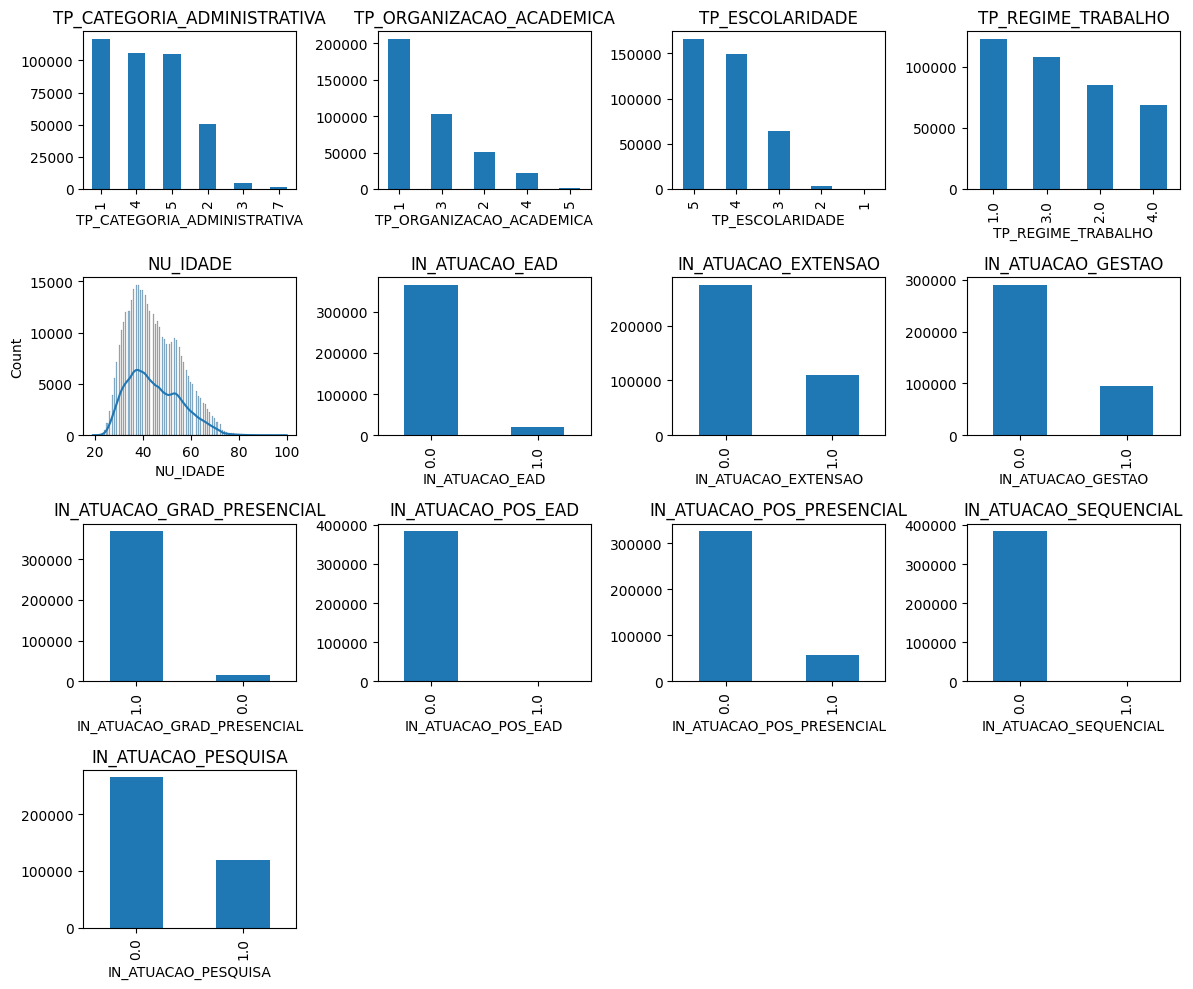

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, df_docente_anonimizado.columns):
    if df_docente_anonimizado[col].dtype.name == "category":
        df_docente_anonimizado[col].value_counts().plot.bar(ax=ax)
        ax.set_title(col)
    else:
        sns.histplot(df_docente_anonimizado[col], ax=ax, kde=True)
        ax.set_title(col)

# Remove axes não usados
for j in range(len(df_docente_anonimizado.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Tratamento Categóricas - One-Hot Encoding

As variáveis categóricas foram transformadas por one‑hot encoding para evitar que algoritmos interpretem ordens numéricas inexistentes entre categorias.

Antes da codificação, mapeamentos semânticos foram aplicados para gerar rótulos legíveis e facilitar interpretação das features resultantes. Para controlar o aumento dimensional e o uso de memória, as colunas resultantes foram convertidas para category quando suportado e categorias de baixa cardinalidade foram mantidas, essa estratégia preserva a informação categórica sem introduzir ordens artificiais e prepara os dados para modelos lineares e baseados em distância.

Para trabalhos futuros fica a possibilidade de agrupamento de variáveis raras para outros, para melhorar a descriminação dos dados.

Análise: existem valores NaN ou vazios?

Importante para aplicar o One-Hot Encoding

In [ ]:
print("Contagem de valores nulos (NaN) por coluna em df_docente_anonimizado:")
missing_values = df_docente_anonimizado.isnull().sum()
# Filtrar e exibir apenas as colunas com valores nulos
missing_values = missing_values[missing_values > 0]

if not missing_values.empty:
    display(missing_values)
else:
    print("\t Nenhuma coluna no df_docente_anonimizado possui valores nulos.")

Contagem de valores nulos (NaN) por coluna em df_docente_anonimizado:
	 Nenhuma coluna no df_docente_anonimizado possui valores nulos.


Validação da feature `NU_IDADE` se tem alguém menor que 18 anos ou maior que 100 anos, afim de detectar erros cadastrais ou outliers ou ruídos.

In [ ]:
# Filtrar idades
idades_invalidas = df_docente_anonimizado[(df_docente_anonimizado['NU_IDADE'] > 100) | (df_docente_anonimizado['NU_IDADE'] < 18)]

if not idades_invalidas.empty:
    print("Registros com idade maior que 100 anos ou menor que 18 anos:")
    display(idades_invalidas[['NU_IDADE']])
    print(f"Total de registros: {len(idades_invalidas)}")
else:
    print("\t Não foram encontrados registros com idade maior que 100 anos ou menor que 18 anos no `df_docente_anonimizado`.")

	 Não foram encontrados registros com idade maior que 100 anos ou menor que 18 anos no `df_docente_anonimizado`.


In [ ]:
# Mapeamentos fornecidos pelo usuário
map_categoria_administrativa = {
    1: 'Publica_Federal',
    2: 'Publica_Estadual',
    3: 'Publica_Municipal',
    4: 'Privada_Com_Fins_Lucrativos',
    5: 'Privada_Sem_Fins_Lucrativos',
    6: 'Privada_Particular_Estrito_Sentido',
    7: 'Especial',
    8: 'Privada_Comunitaria',
    9: 'Privada_Confessional'
}

map_organizacao_academica = {
    1: 'Universidade',
    2: 'Centro_Universitario',
    3: 'Faculdade',
    4: 'Instituto_Federal_Educacao_Ciencia_Tecnologia',
    5: 'Centro_Federal_Educacao_Tecnologica'
}

map_escolaridade = {
    1: 'Sem_Graduacao',
    2: 'Graduacao',
    3: 'Especializacao',
    4: 'Mestrado',
    5: 'Doutorado'
}

map_regime_trabalho = {
    1: 'Tempo_Integral_Com_Dedicao_Exclusiva',
    2: 'Tempo_Integral_Sem_Dedicao_Exclusiva',
    3: 'Tempo_Parcial',
    4: 'Horista'
}

# Criar uma cópia para evitar modificar o DataFrame original durante a iteração
df_tratado = df_docente_anonimizado.copy()

# Lista de colunas a serem transformadas
columns_to_encode = {
    'TP_CATEGORIA_ADMINISTRATIVA': map_categoria_administrativa,
    'TP_ORGANIZACAO_ACADEMICA': map_organizacao_academica,
    'TP_ESCOLARIDADE': map_escolaridade,
    'TP_REGIME_TRABALHO': map_regime_trabalho
}

for col, mapping in columns_to_encode.items():
    # Substitui os valores numéricos pelos rótulos descritivos
    df_tratado[col] = df_tratado[col].map(mapping)

    # Aplica One-Hot Encoding com nomes legíveis
    dummies = pd.get_dummies(df_tratado[col], prefix=col, prefix_sep='_').astype('category')

    # Concatena os dummies
    df_tratado = pd.concat([df_tratado, dummies], axis=1)

    # Remove a coluna original
    df_tratado = df_tratado.drop(columns=[col])

display(df_tratado)

,NU_IDADE,IN_ATUACAO_EAD,IN_ATUACAO_EXTENSAO,IN_ATUACAO_GESTAO,IN_ATUACAO_GRAD_PRESENCIAL,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA,TP_CATEGORIA_ADMINISTRATIVA_Publica_Federal,...,TP_ORGANIZACAO_ACADEMICA_Centro_Federal_Educacao_Tecnologica,TP_ESCOLARIDADE_Sem_Graduacao,TP_ESCOLARIDADE_Graduacao,TP_ESCOLARIDADE_Especializacao,TP_ESCOLARIDADE_Mestrado,TP_ESCOLARIDADE_Doutorado,TP_REGIME_TRABALHO_Tempo_Integral_Com_Dedicao_Exclusiva,TP_REGIME_TRABALHO_Tempo_Integral_Sem_Dedicao_Exclusiva,TP_REGIME_TRABALHO_Tempo_Parcial,TP_REGIME_TRABALHO_Horista
0,61,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,True,...,False,False,False,False,False,True,False,True,False,False
1,66,0.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00,True,...,False,False,False,False,False,True,True,False,False,False
2,49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,True,...,False,False,False,False,True,False,True,False,False,False
3,63,0.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00,True,...,False,False,False,True,False,False,True,False,False,False
4,53,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,True,...,False,False,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397888,45,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,False,...,False,False,False,False,True,False,False,False,False,True
397889,39,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,False,...,False,False,False,False,False,True,False,False,False,True
397890,53,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,False,...,False,False,False,False,False,True,False,False,False,True
397891,63,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,False,...,False,False,False,False,False,True,False,False,False,True


In [ ]:
print(f"Antes de One-Hot:     {df_docente_anonimizado.shape[1]}")
print(f"Após aplicar One-Hot: {df_tratado.shape[1]}")
print(f"Delta adição:         {df_tratado.shape[1] - df_docente_anonimizado.shape[1]}")

Antes de One-Hot:     13
Após aplicar One-Hot: 29
Delta adição:         16


## Linhas&Colunas Pós Tratamento

Aqui demonstramos, o estado do conjunto de dados após as etapas de limpeza, conversões de tipo, e antes de qualquer codificação final, normalização adicional ou divisão treino teste. Aqui estão registradas as operações realizadas até esse ponto e o resultado imediato em termos de linhas, colunas e tipos de dados.

In [ ]:
print(f"Tamanho do dataset final = {len(df_tratado):,}")
print(f"Quantidade de variáveis  = {len(df_tratado.columns):,}")

Tamanho do dataset final = 384,474
Quantidade de variáveis  = 29


In [ ]:
df_tratado.info(verbose=True, memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 384474 entries, 0 to 397892
Data columns (total 29 columns):
 #   Column                                                                  Non-Null Count   Dtype   
---  ------                                                                  --------------   -----   
 0   NU_IDADE                                                                384474 non-null  uint8   
 1   IN_ATUACAO_EAD                                                          384474 non-null  category
 2   IN_ATUACAO_EXTENSAO                                                     384474 non-null  category
 3   IN_ATUACAO_GESTAO                                                       384474 non-null  category
 4   IN_ATUACAO_GRAD_PRESENCIAL                                              384474 non-null  category
 5   IN_ATUACAO_POS_EAD                                                      384474 non-null  category
 6   IN_ATUACAO_POS_PRESENCIAL                                        

Menos de 10MB, mesmo com 380k+ padrões.

# Conhecendo a base


Agora vamos conhecer essa base... vamos usar o que puder de poder estatístico para entender, algumas coisas já entendemos... não tem nan e vazia, as idades parecem estar dentro de um range aceitável... agora é vermos essas distribuições

## Dados estatísticos e variância

   * `count`: Não-nulos
   * `unique`: Distintos
   * `top`: Moda
   * `freq`: Frequência da Moda

In [ ]:
describe_pre_outliers = df_tratado.select_dtypes("category").describe()
describe_pre_outliers

,IN_ATUACAO_EAD,IN_ATUACAO_EXTENSAO,IN_ATUACAO_GESTAO,IN_ATUACAO_GRAD_PRESENCIAL,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA,TP_CATEGORIA_ADMINISTRATIVA_Publica_Federal,TP_CATEGORIA_ADMINISTRATIVA_Publica_Estadual,...,TP_ORGANIZACAO_ACADEMICA_Centro_Federal_Educacao_Tecnologica,TP_ESCOLARIDADE_Sem_Graduacao,TP_ESCOLARIDADE_Graduacao,TP_ESCOLARIDADE_Especializacao,TP_ESCOLARIDADE_Mestrado,TP_ESCOLARIDADE_Doutorado,TP_REGIME_TRABALHO_Tempo_Integral_Com_Dedicao_Exclusiva,TP_REGIME_TRABALHO_Tempo_Integral_Sem_Dedicao_Exclusiva,TP_REGIME_TRABALHO_Tempo_Parcial,TP_REGIME_TRABALHO_Horista
count,384474.00,384474.00,384474.00,384474.00,384474.00,384474.00,384474.00,384474.00,384474,384474,...,384474,384474,384474,384474,384474,384474,384474,384474,384474,384474
unique,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2,2,...,2,2,2,2,2,2,2,2,2,2
top,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,False,False,...,False,False,False,False,False,False,False,False,False,False
freq,365024.00,274473.00,290250.00,368801.00,383464.00,326774.00,384108.00,264960.00,267431,334089,...,383035,384456,380693,319937,234699,218111,261665,299330,276430,315997


Para a única coluna com número:

In [ ]:
stats_pre_outliers = df_tratado["NU_IDADE"].describe()
stats_pre_outliers.loc['var'] = df_tratado["NU_IDADE"].var().tolist()
stats_pre_outliers

,NU_IDADE
count,384474.00
mean,44.62
std,10.94
min,19.00
25%,36.00
50%,43.00
75%,52.00
max,100.00
var,119.75


## Correlações - Spearman

Spearman é uma medida de associação **monotônica** baseada no **ranking** dos valores, não nos valores absolutos. Apropriada quando:

- **(nosso caso)** a maior parte das variáveis é categórica ordinal ou binária;
- a relação esperada entre as variáveis não precisa ser linear;
- distribuições assimétricas ou altamente discretizadas;
- muitos empates nos valores (comum para variáveis categóricas).

Será mais robusta que Pearson aqui porque:
- não assume linearidade nem distribuição contínua;
- captura padrões estruturais mesmo com variáveis categóricas;
- permite visualizar redundância, dependência monotônica e colinearidade.

A fórmula é feia, mas um tanto quanto elegante. Para variáveis $X_i$ e $Y_i$:
$$
\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}
$$

- $d_i$ é a diferença entre os rankings dos pares $X_i$ e $Y_i$;
- $n$ é o número de observações.


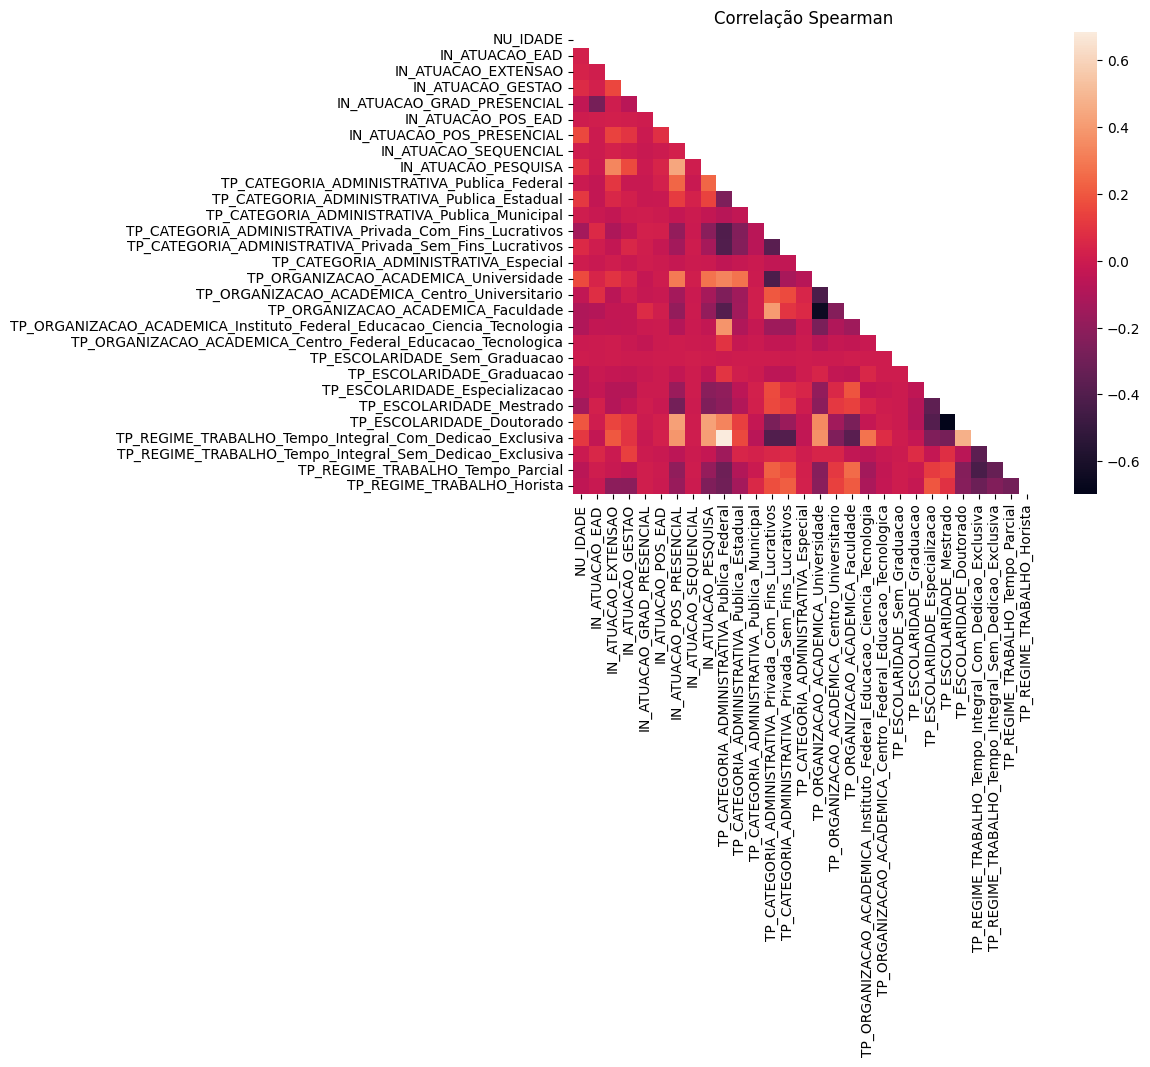

In [ ]:
corr = df_tratado.corr(method="spearman")

# máscara para ocultar o triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=False,
    cmap="rocket",
    square=True,
    cbar=True
)
plt.title("Correlação Spearman")
plt.show()

> Algumas correlações altas!

> Como elas estão distribuídas?

In [ ]:
# transformar em long form
corrs_pairs = (
    # triângulo inferior
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
corrs_pairs.columns = ["var1", "var2", "spearman"]
corrs_pairs.describe()


,spearman
count,406.00
mean,-0.02
std,0.16
min,-0.70
25%,-0.06
50%,-0.01
75%,0.02
max,0.68


> Média bem baixa, com poucos valores elevados.

In [ ]:
# pegar as mais relacionadas
limiar = 0.5
corrs_fortes = corrs_pairs[abs(corrs_pairs["spearman"]) >= limiar]
corrs_fortes.sort_values("spearman", ascending=True)

,var1,var2,spearman
299,TP_ESCOLARIDADE_Doutorado,TP_ESCOLARIDADE_Mestrado,-0.70
151,TP_ORGANIZACAO_ACADEMICA_Faculdade,TP_ORGANIZACAO_ACADEMICA_Universidade,-0.65
309,TP_REGIME_TRABALHO_Tempo_Integral_Com_Dedicao_...,TP_CATEGORIA_ADMINISTRATIVA_Publica_Federal,0.68


## Tratamento de outliers

### Linhas/Atributo Antes

In [ ]:
df_tratado_antes_analise_outliers = len(df_tratado)
df_tratado.count().apply(lambda x: f"{x:,}")

,0
NU_IDADE,"384,474"
IN_ATUACAO_EAD,"384,474"
IN_ATUACAO_EXTENSAO,"384,474"
IN_ATUACAO_GESTAO,"384,474"
IN_ATUACAO_GRAD_PRESENCIAL,"384,474"
IN_ATUACAO_POS_EAD,"384,474"
IN_ATUACAO_POS_PRESENCIAL,"384,474"
IN_ATUACAO_SEQUENCIAL,"384,474"
IN_ATUACAO_PESQUISA,"384,474"
TP_CATEGORIA_ADMINISTRATIVA_Publica_Federal,"384,474"


Todos com exatamente `len(df)`, então sem valores faltantes.

### Remoção Outliers

Aqui utilizaremos a função tratar_outliers, que seu comportamento foi explicado anteriormente.

In [ ]:
df_treinamento = tratar_outliers(df_tratado)
df_tratado_depois_analise_outliers = len(df_treinamento)

Passou removendo z-scores >= 3 manualmente


### Linhas/Atributo Depois

In [ ]:
df_treinamento.count().apply(lambda x: f"{x:,}")

,0
NU_IDADE,"383,731"
IN_ATUACAO_EAD,"383,731"
IN_ATUACAO_EXTENSAO,"383,731"
IN_ATUACAO_GESTAO,"383,731"
IN_ATUACAO_GRAD_PRESENCIAL,"383,731"
IN_ATUACAO_POS_EAD,"383,731"
IN_ATUACAO_POS_PRESENCIAL,"383,731"
IN_ATUACAO_SEQUENCIAL,"383,731"
IN_ATUACAO_PESQUISA,"383,731"
TP_CATEGORIA_ADMINISTRATIVA_Publica_Federal,"383,731"


### Quantidade do corte

In [ ]:
df_tratado_antes_analise_outliers - df_tratado_depois_analise_outliers

743

### Describe/Var Depois

In [ ]:
describe_post_outliers = df_treinamento.select_dtypes("category").describe()
describe_post_outliers

,IN_ATUACAO_EAD,IN_ATUACAO_EXTENSAO,IN_ATUACAO_GESTAO,IN_ATUACAO_GRAD_PRESENCIAL,IN_ATUACAO_POS_EAD,IN_ATUACAO_POS_PRESENCIAL,IN_ATUACAO_SEQUENCIAL,IN_ATUACAO_PESQUISA,TP_CATEGORIA_ADMINISTRATIVA_Publica_Federal,TP_CATEGORIA_ADMINISTRATIVA_Publica_Estadual,...,TP_ORGANIZACAO_ACADEMICA_Centro_Federal_Educacao_Tecnologica,TP_ESCOLARIDADE_Sem_Graduacao,TP_ESCOLARIDADE_Graduacao,TP_ESCOLARIDADE_Especializacao,TP_ESCOLARIDADE_Mestrado,TP_ESCOLARIDADE_Doutorado,TP_REGIME_TRABALHO_Tempo_Integral_Com_Dedicao_Exclusiva,TP_REGIME_TRABALHO_Tempo_Integral_Sem_Dedicao_Exclusiva,TP_REGIME_TRABALHO_Tempo_Parcial,TP_REGIME_TRABALHO_Horista
count,383731.00,383731.00,383731.00,383731.00,383731.00,383731.00,383731.00,383731.00,383731,383731,...,383731,383731,383731,383731,383731,383731,383731,383731,383731,383731
unique,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2,2,...,2,2,2,2,2,2,2,2,2,2
top,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,False,False,...,False,False,False,False,False,False,False,False,False,False
freq,364303.00,273906.00,289685.00,368182.00,382723.00,326177.00,383365.00,264442.00,266705,333380,...,382292,383713,379957,319350,234134,217770,260955,298798,275993,315447


In [ ]:
stats_post_outliers = df_treinamento["NU_IDADE"].describe()
stats_post_outliers.loc['var'] = df_treinamento["NU_IDADE"].var().tolist()
stats_post_outliers

,NU_IDADE
count,383731.00
mean,44.54
std,10.83
min,19.00
25%,36.00
50%,43.00
75%,52.00
max,77.00
var,117.38


### Diferença Depois

In [ ]:
stats_post_outliers - stats_pre_outliers

,NU_IDADE
count,-743.00
mean,-0.07
std,-0.11
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,-23.00
var,-2.37


> Para a var. numérica, houve mudança somente **contagem**, no valor **máximo**, e um pouco na **variância**.

In [ ]:
pd.DataFrame([stats_pre_outliers, stats_post_outliers])

,count,mean,std,min,25%,50%,75%,max,var
NU_IDADE,384474.00,44.62,10.94,19.00,36.00,43.00,52.00,100.00,119.75
NU_IDADE,383731.00,44.54,10.83,19.00,36.00,43.00,52.00,77.00,117.38


### Linhas&Colunas Pós Outliers

In [ ]:
print(f"Tamanho do dataset de treino = {len(df_treinamento):,}")
print(f"Quantidade de variáveis      = {len(df_treinamento.columns):,}")

Tamanho do dataset de treino = 383,731
Quantidade de variáveis      = 29


## Remover variáveis sem variância

Vamos avaliar direito isso aqui, eu acho que vamos precisar desses outliers, na verdade foram considerados assim, pq existem poucos registros:

['IN_ATUACAO_EAD', 'IN_ATUACAO_GRAD_PRESENCIAL', 'IN_ATUACAO_POS_EAD', 'IN_ATUACAO_SEQUENCIAL', 'TP_CATEGORIA_ADMINISTRATIVA_Especial', 'TP_CATEGORIA_ADMINISTRATIVA_Publica_Municipal', 'TP_ORGANIZACAO_ACADEMICA_Centro_Federal_Educacao_Tecnologica', 'TP_ORGANIZACAO_ACADEMICA_Instituto_Federal_Educacao_Ciencia_Tecnologia', 'TP_ESCOLARIDADE_Graduacao', 'TP_ESCOLARIDADE_Sem_Graduacao']

In [ ]:
# df_treinamento_com_variancia = remover_variaveis_sem_variancia(df_treinamento)
# ↪ Logo, usamos apenas `df_treinamento` normalmente

In [ ]:
df_treinamento_com_variancia = df_treinamento.copy()

## Correlações - Target (`IN_ATUAÇAO_PESQUISA`)

In [ ]:
# Calcular a correlação de todas as colunas com 'IN_ATUACAO_PESQUISA'
# ↪ já está presente por conta do cálculo anterior usando Spearman
correlations = corr

# Remover quaisquer valores NaN da série de correlações antes de selecionar top/bottom
# correlations_cleaned = correlations.dropna()
# ↪ já não há NaN's na matriz calculada
correlations_cleaned = corr

Então, como nossa _target_ se relaciona com o resto dos atributos?

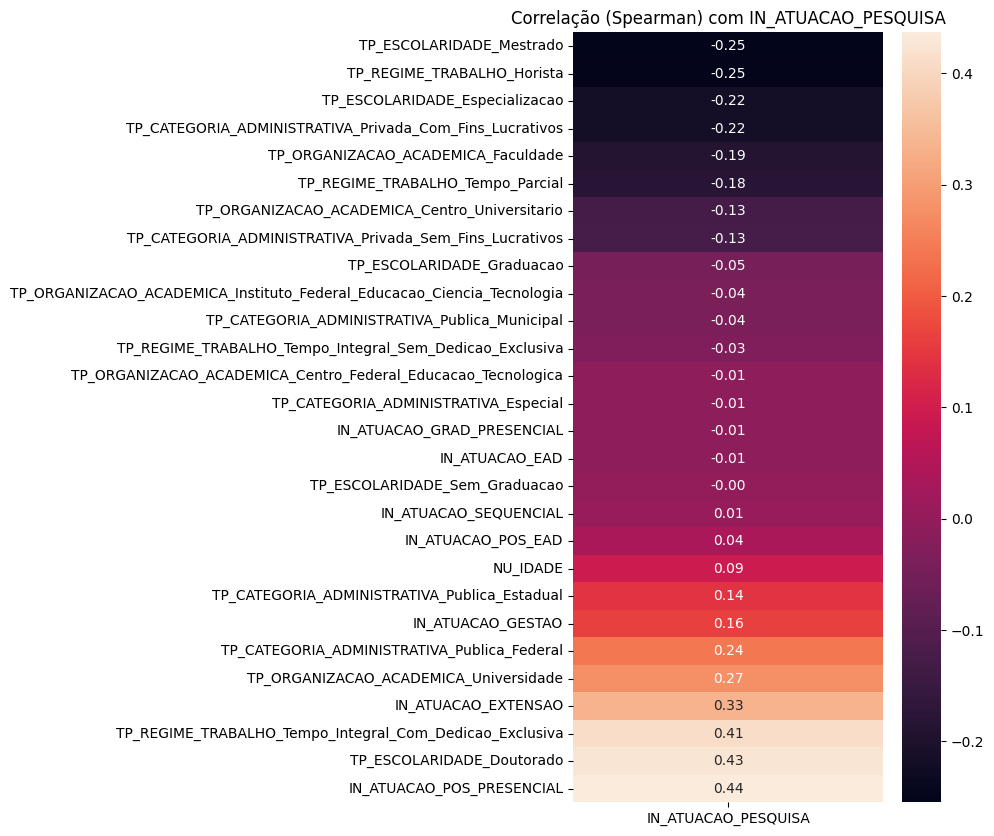

In [ ]:
# Selecionar apenas a coluna da correlação com a target (DF de 1 coluna)
target_corr = corr[['IN_ATUACAO_PESQUISA']]

# Dropar a própria correlação com ela mesma
target_corr = target_corr.drop(index='IN_ATUACAO_PESQUISA')

plt.figure(figsize=(5, 10))
sns.heatmap(
    target_corr.sort_values('IN_ATUACAO_PESQUISA', ascending=True),
    annot=True,
    fmt=".2f",
    cmap="rocket",
    cbar=True
)
plt.title("Correlação (Spearman) com IN_ATUACAO_PESQUISA")
plt.tight_layout()
plt.show()

Top e Bottom 10 correlações (excluindo a consigo mesma de 1.0):

In [ ]:
# --- 1. Selecionar apenas a linha da target ---
# correlations_cleaned deve ser a série de correlações com a target
correlations_cleaned = corr["IN_ATUACAO_PESQUISA"]

# excluir a própria variável alvo
cor_target = correlations_cleaned.drop(labels=['IN_ATUACAO_PESQUISA'], errors='ignore')

# --- 2. Ordenar para pegar maiores e menores ---
cor_sorted = cor_target.sort_values(ascending=False)

top_10_pos = cor_sorted.head(10)
top_10_neg = cor_sorted.tail(10)

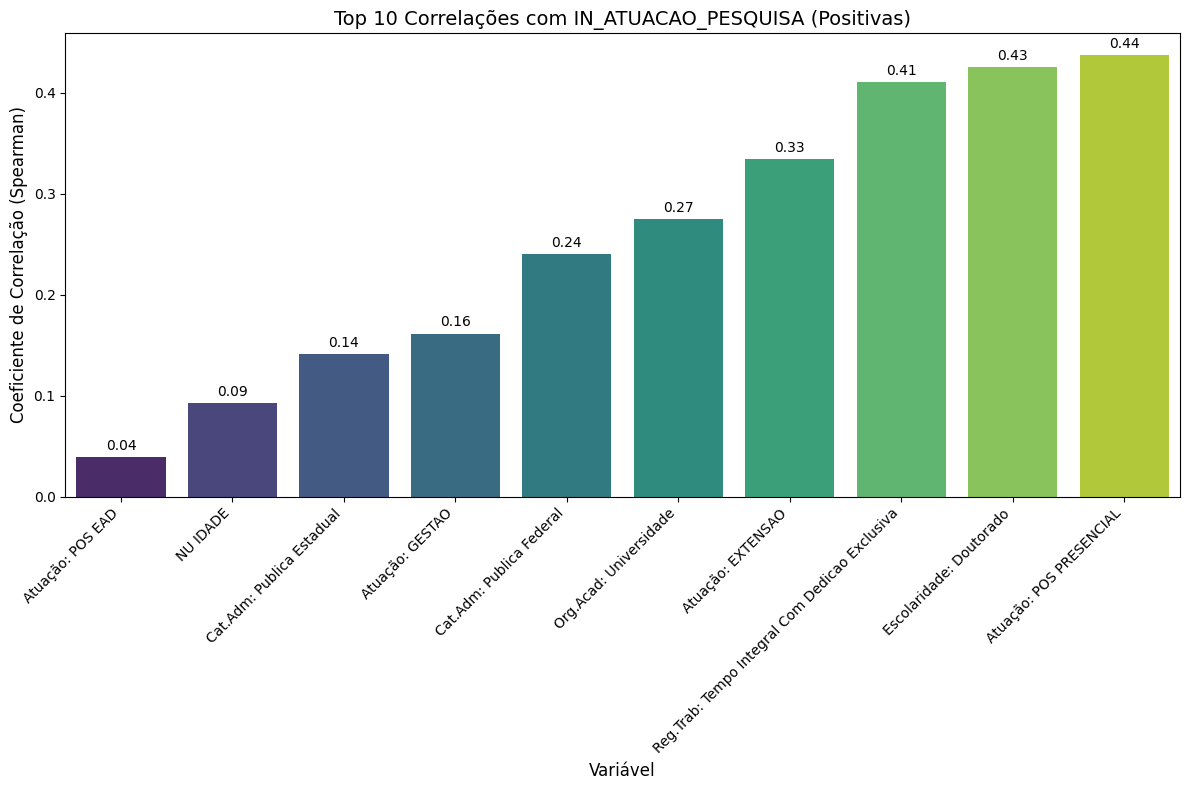

In [ ]:
# --- 3. Plot positivos ---
top_10_pos_sorted = top_10_pos.sort_values(ascending=True)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=top_10_pos_sorted.index.map(format_corr_label),
    y=top_10_pos_sorted.values,
    palette='viridis'
)

plt.title('Top 10 Correlações com IN_ATUACAO_PESQUISA (Positivas)', fontsize=14)
plt.xlabel('Variável', fontsize=12)
plt.ylabel('Coeficiente de Correlação (Spearman)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

# --- anotações ---
for bar, value in zip(ax.patches, top_10_pos_sorted.values):
    height = bar.get_height()
    ax.annotate(
        f"{value:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

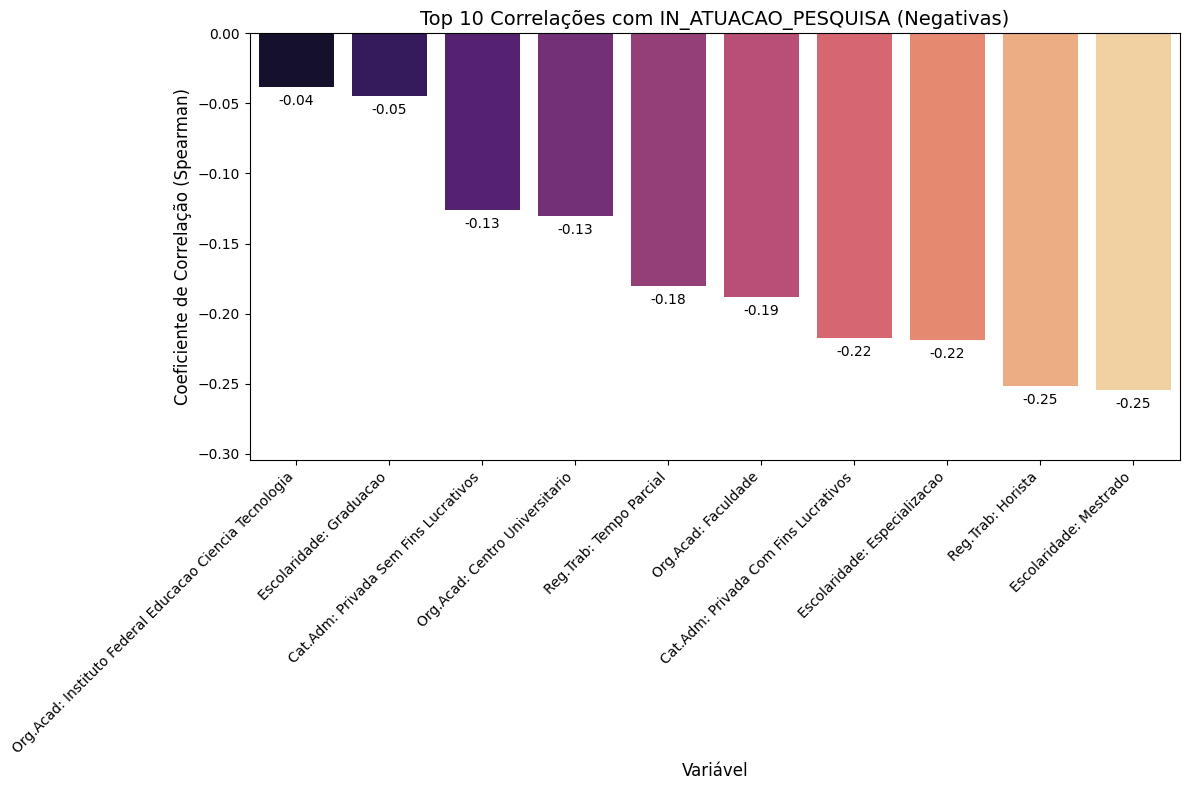

In [ ]:
# --- 4. Plot negativos ---
top_10_neg_sorted = top_10_neg.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=top_10_neg_sorted.index.map(format_corr_label),
    y=top_10_neg_sorted.values,
    palette='magma'
)

plt.title('Top 10 Correlações com IN_ATUACAO_PESQUISA (Negativas)', fontsize=14)
plt.xlabel('Variável', fontsize=12)
plt.ylabel('Coeficiente de Correlação (Spearman)', fontsize=12)

# deixar espaço para valores negativos
min_corr_neg = top_10_neg_sorted.min() - 0.05
plt.ylim(min_corr_neg, 0)

plt.xticks(rotation=45, ha='right', fontsize=10)

# --- anotações ---
for bar, value in zip(ax.patches, top_10_neg_sorted.values):
    height = bar.get_height()
    ax.annotate(
        f"{value:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, -15),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Distribuição `NU_IDADE`

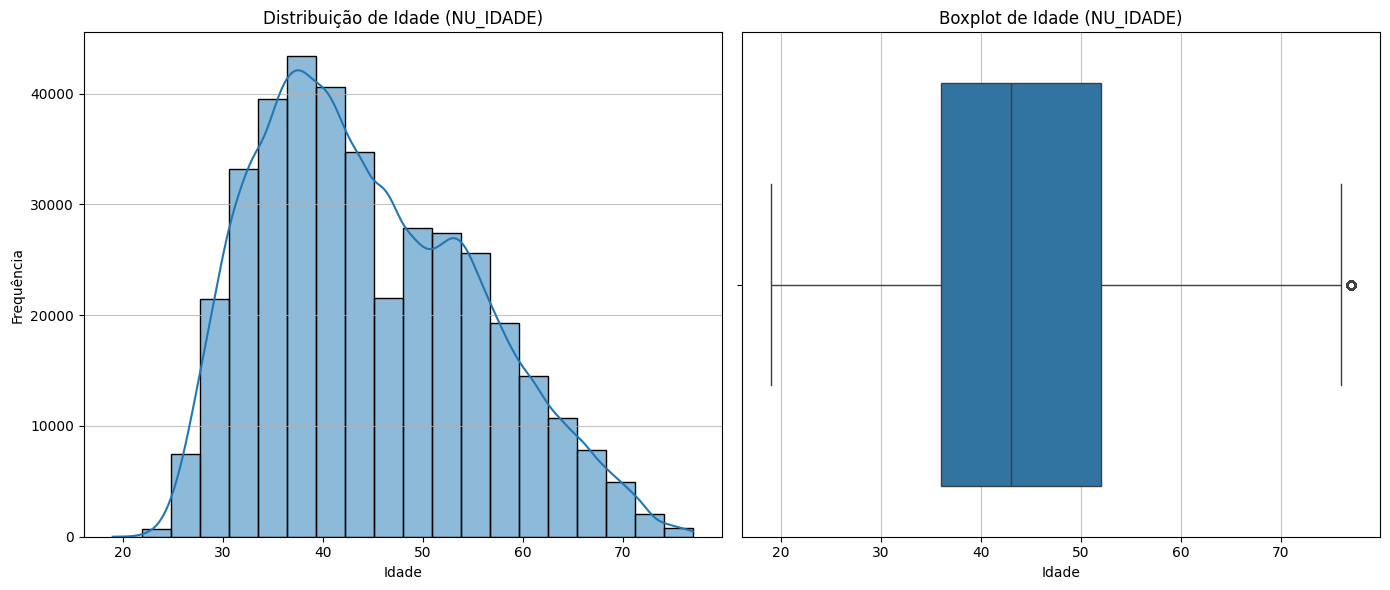

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Histograma ---
sns.histplot(
    df_treinamento['NU_IDADE'],
    bins=20,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Distribuição de Idade (NU_IDADE)')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
axes[0].grid(axis='y', alpha=0.75)

# --- Boxplot ---
sns.boxplot(
    x=df_treinamento['NU_IDADE'],
    ax=axes[1]
)
axes[1].set_title('Boxplot de Idade (NU_IDADE)')
axes[1].set_xlabel('Idade')
axes[1].grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

## Visualizações - Binárias

### Correlações - Cramér's V

Cramér's V:

- Associação entre duas variáveis categóricas. Deriva do qui-quadrado ($0 \leq \chi^2 \leq 1$);
- Útil quando dados one-hot, rótulos categóricos, faixas, níveis, etc.

A fórmula é $V = \sqrt{\frac{\chi^2}{[n (k - 1)]}}$ ($k$ é o menor número de categorias entre as duas variáveis).

In [ ]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    k = min(table.shape) - 1
    if k == 0:
        return 0
    return np.sqrt(chi2 / (n * k))

> NOTA-DALTONISMO:
> Paletas acessíveis: `inferno` ou, no seaborn, `rocket`/`mako`. Bom contraste pra deuteranopia.

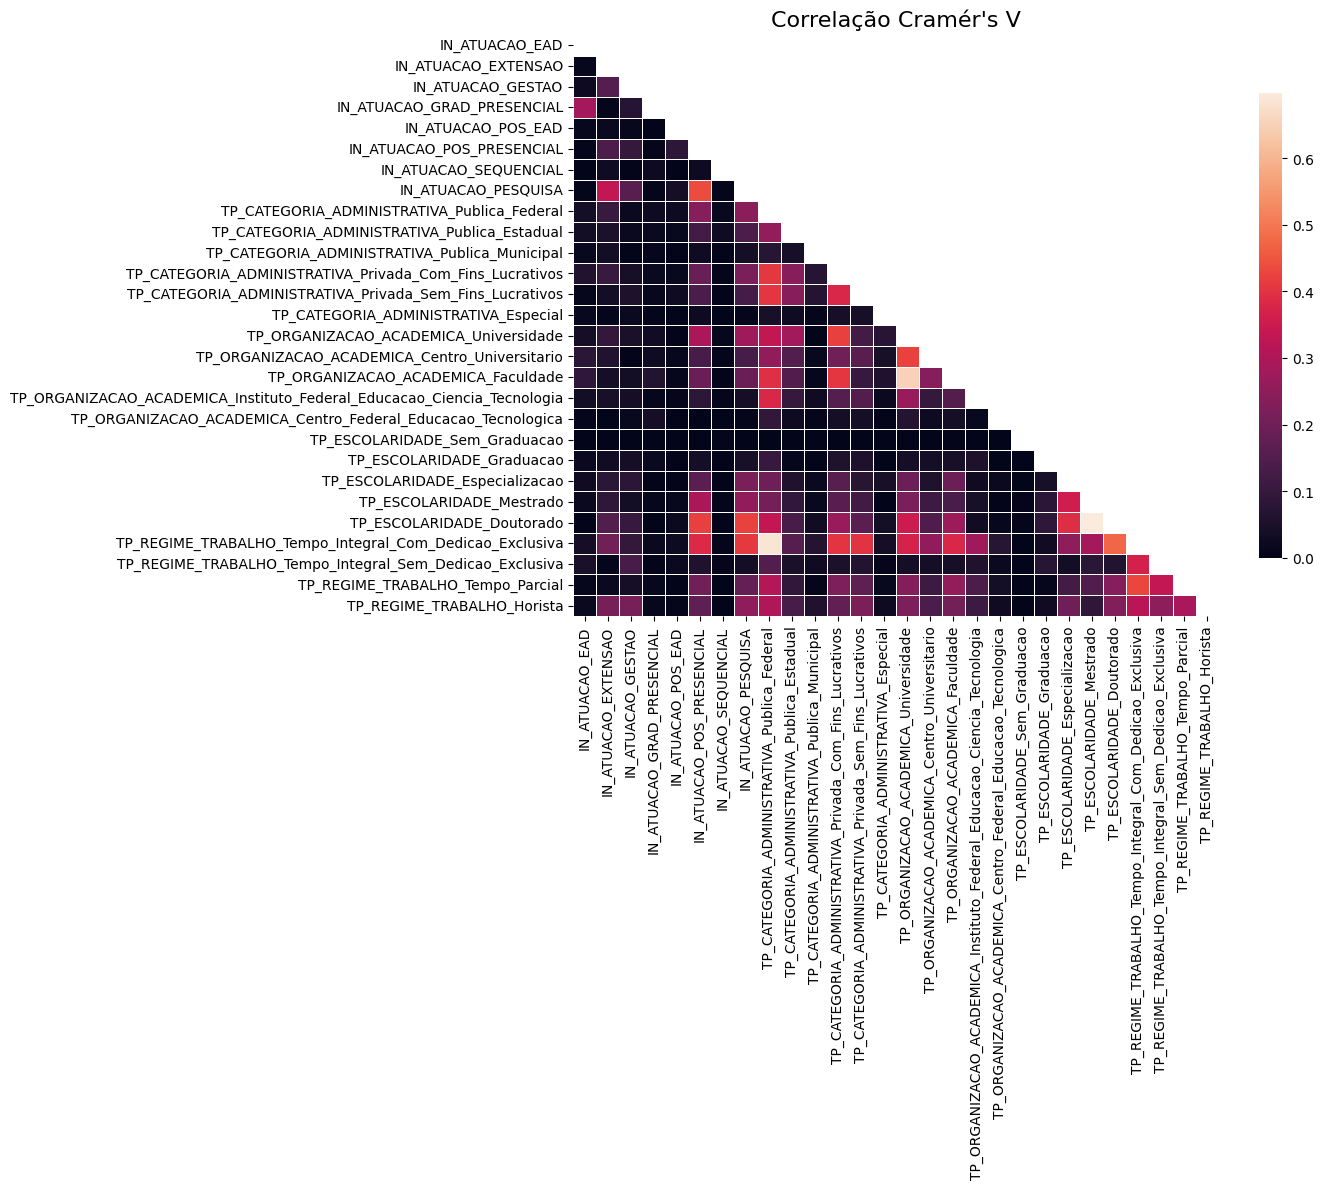

In [ ]:
# Só categóricas
cat_cols = df_treinamento.select_dtypes(include="category").columns

# Matriz vazia
cramers_matrix = pd.DataFrame(np.zeros((len(cat_cols), len(cat_cols))),
                              index=cat_cols, columns=cat_cols)

# Preencher matriz
for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(
            df_treinamento[col1],
            df_treinamento[col2]
        )

# Máscara para triangular inferior
mask = np.triu(np.ones_like(cramers_matrix, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    cramers_matrix,
    cmap="rocket",        # bom pra deuteranopia
    mask=mask,             # só triangular inferior
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title("Correlação Cramér's V", fontsize=16)
plt.tight_layout()
plt.show()

> Algumas correlações altas!

In [ ]:
# transformar em long form
cramers_pairs = (
    # triângulo inferior
    cramers_matrix.where(np.tril(np.ones(cramers_matrix.shape), k=-1).astype(bool))
        .stack()
        .reset_index()
)
cramers_pairs.columns = ["var1", "var2", "cramér's V"]
cramers_pairs.describe()


,cramér's V
count,378.00
mean,0.10
std,0.13
min,0.00
25%,0.01
50%,0.04
75%,0.15
max,0.70


> Novamente, média baixa porém com alguns valores altos específicos

In [ ]:
# pegar as mais relacionadas
limiar = 0.5
cramers_fortes = cramers_pairs[abs(cramers_pairs["cramér's V"]) >= limiar]
cramers_fortes.sort_values("cramér's V", ascending=True)

,var1,var2,cramér's V
134,TP_ORGANIZACAO_ACADEMICA_Faculdade,TP_ORGANIZACAO_ACADEMICA_Universidade,0.65
284,TP_REGIME_TRABALHO_Tempo_Integral_Com_Dedicao_...,TP_CATEGORIA_ADMINISTRATIVA_Publica_Federal,0.68
275,TP_ESCOLARIDADE_Doutorado,TP_ESCOLARIDADE_Mestrado,0.70


### Proportion Plots (todas)

> Condicionados à *target*

> Como cada categoria se distribui dentro dos que pesquisam vs. os que não pesquisam.

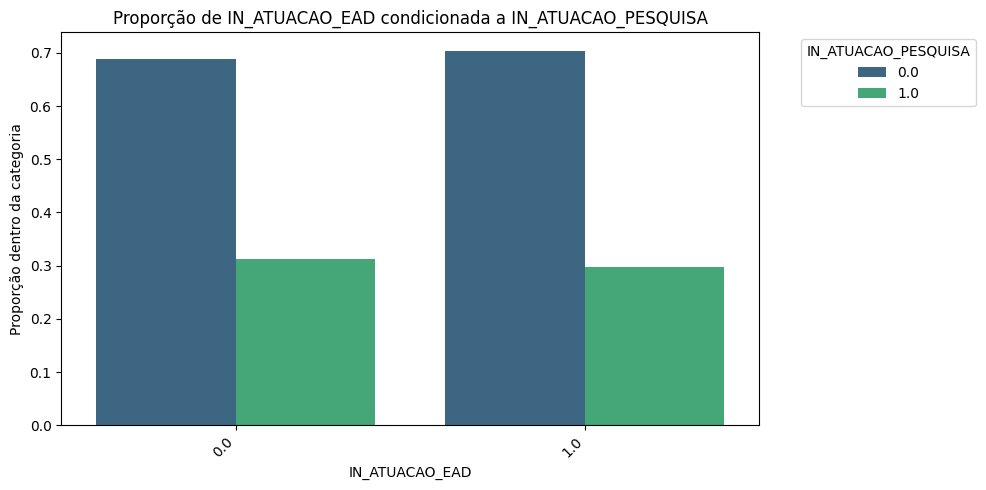

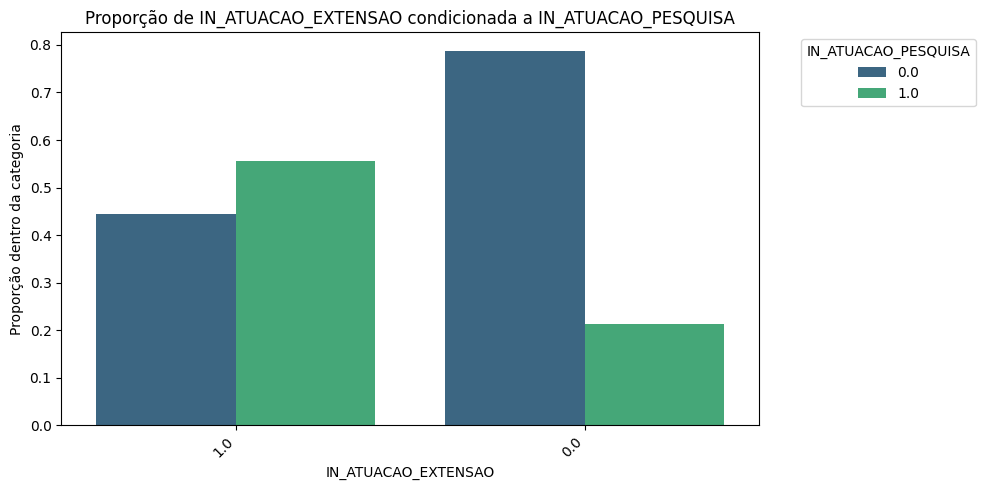

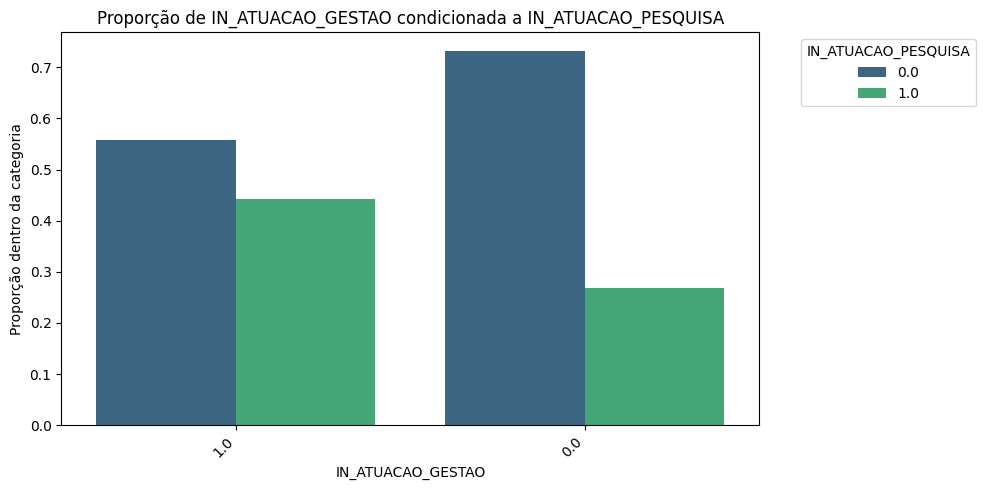

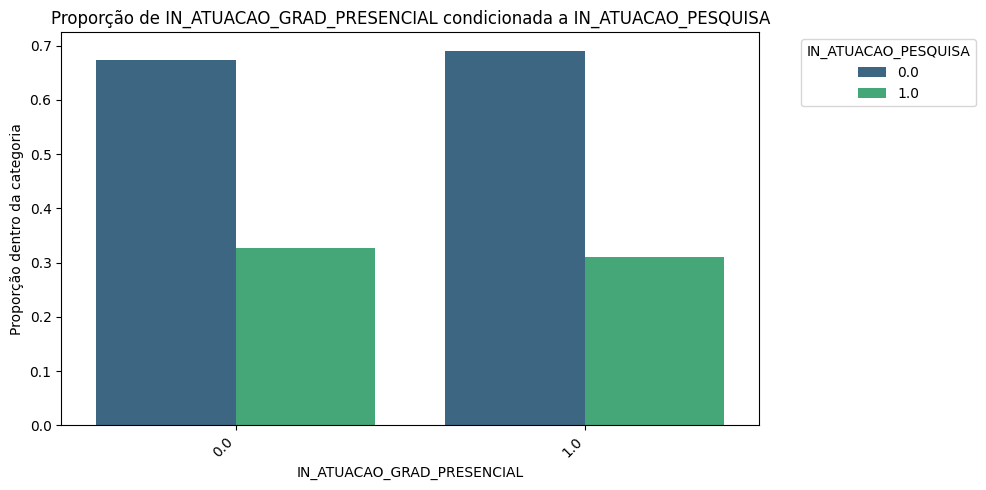

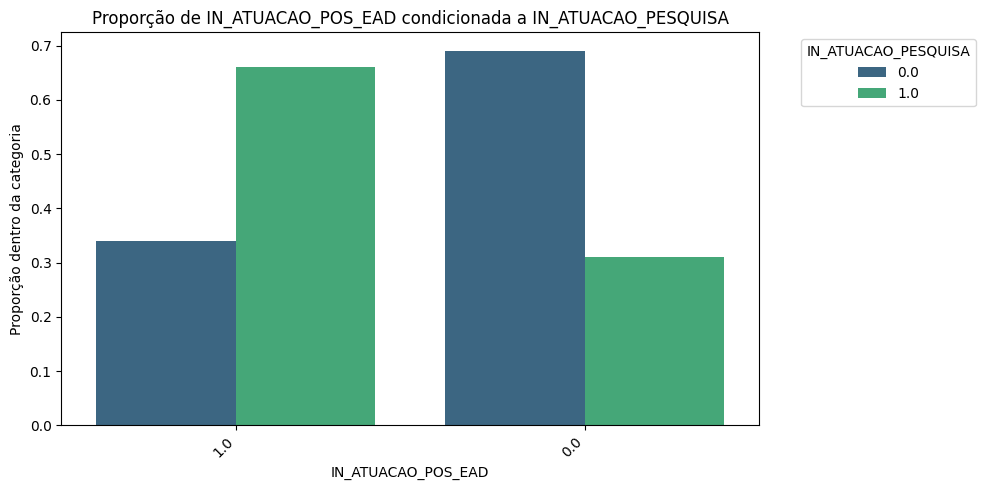

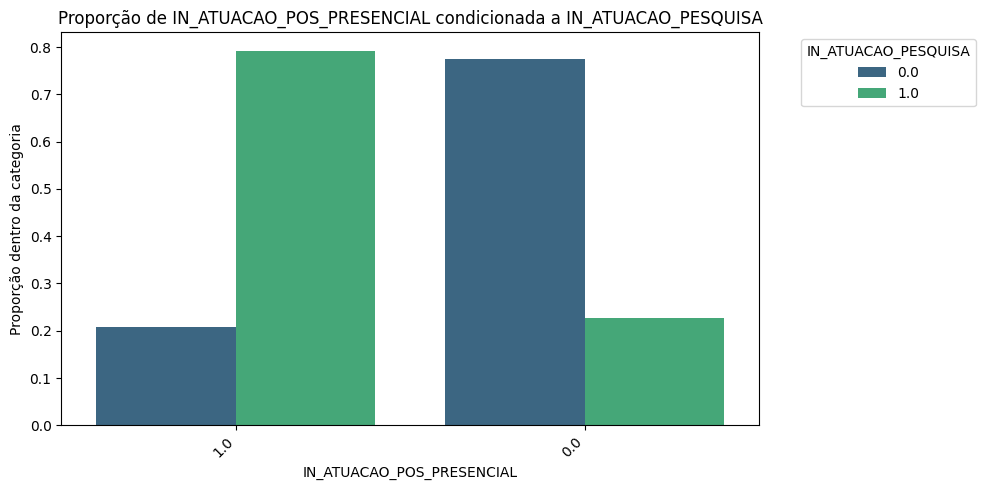

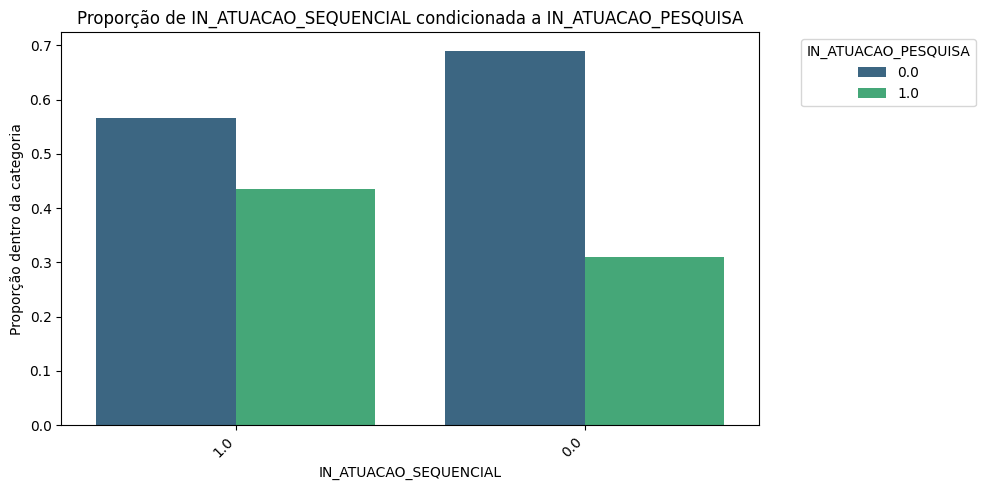

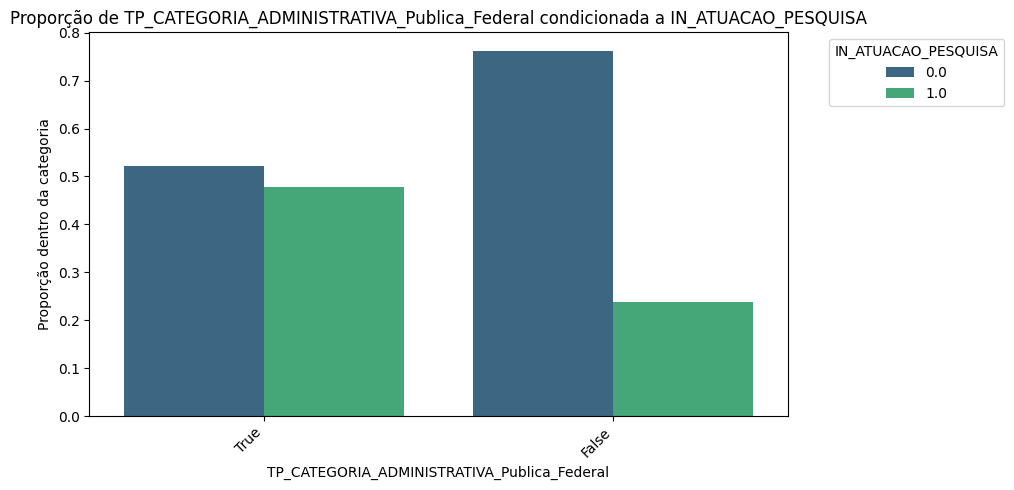

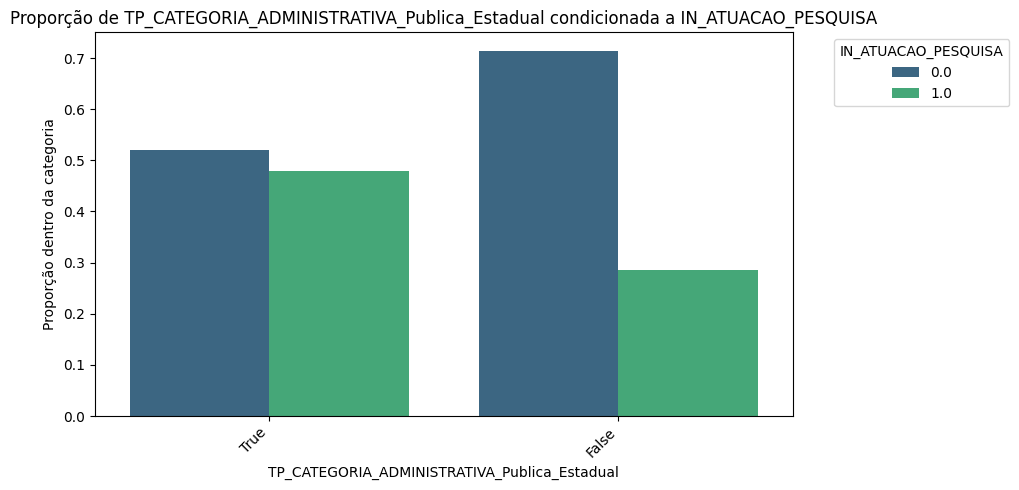

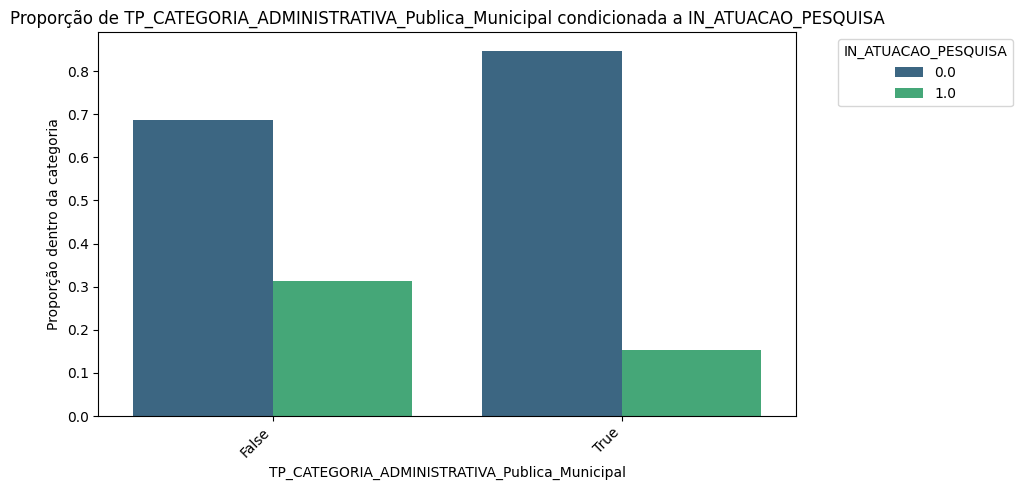

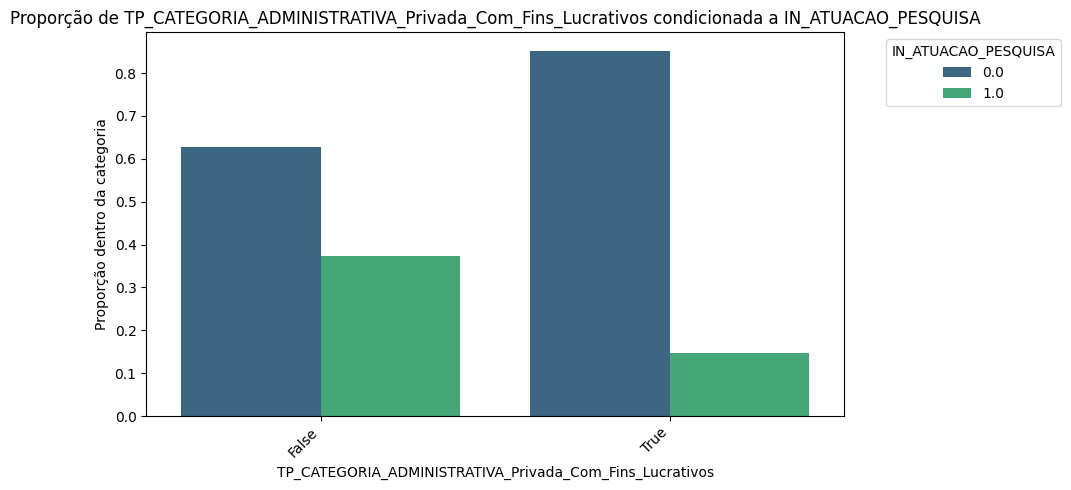

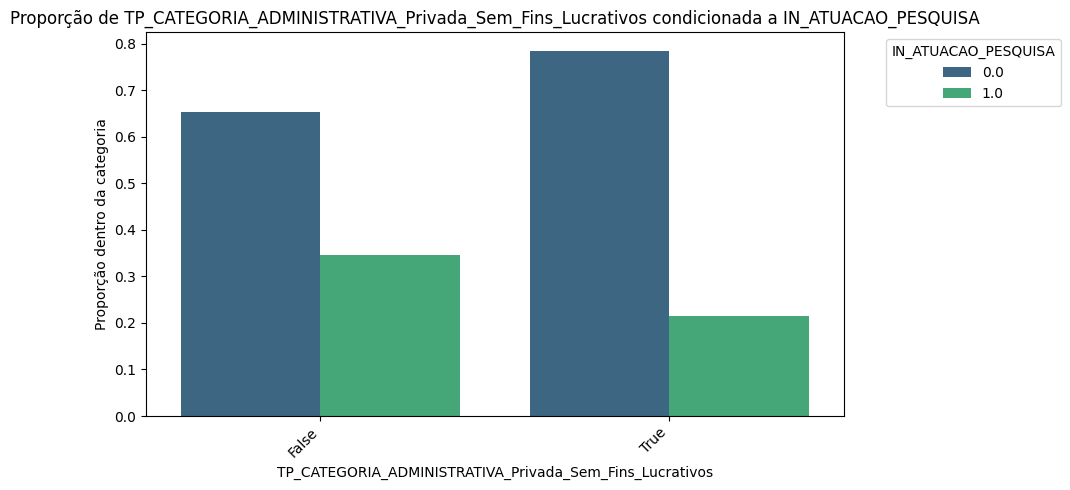

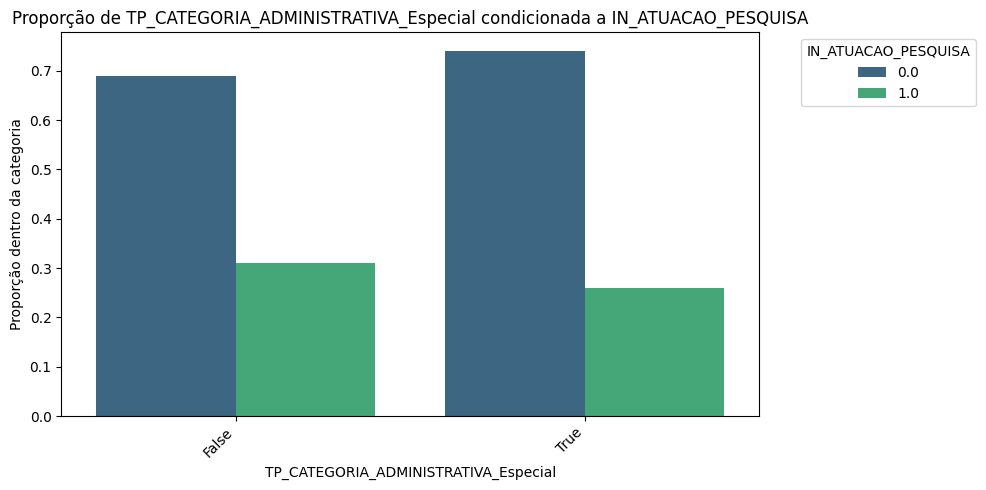

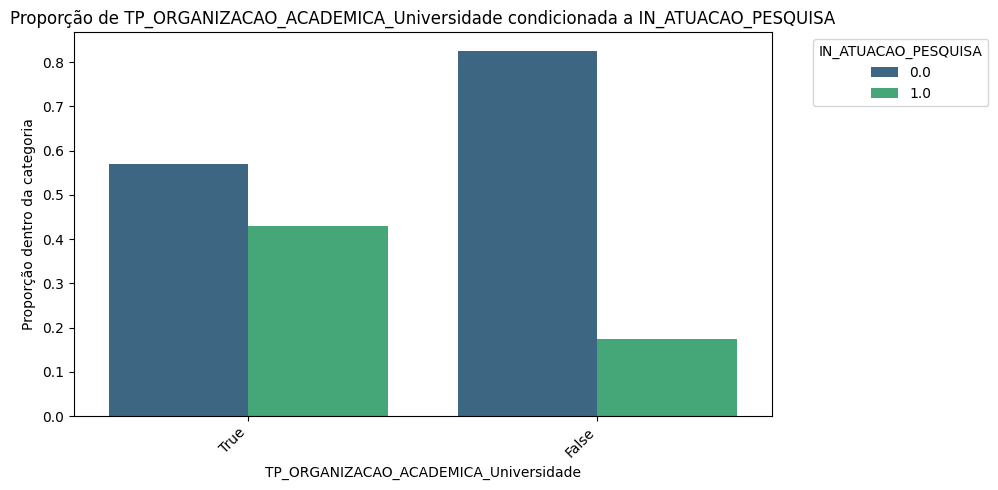

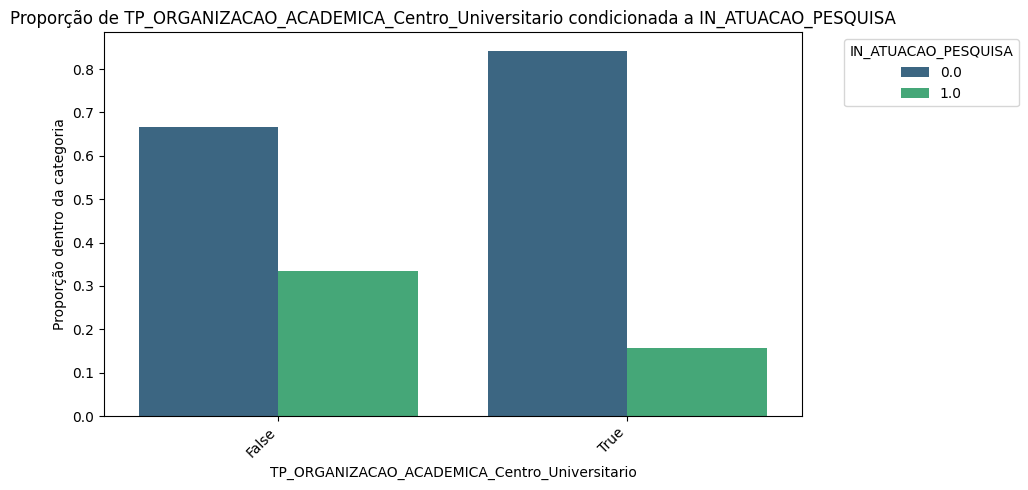

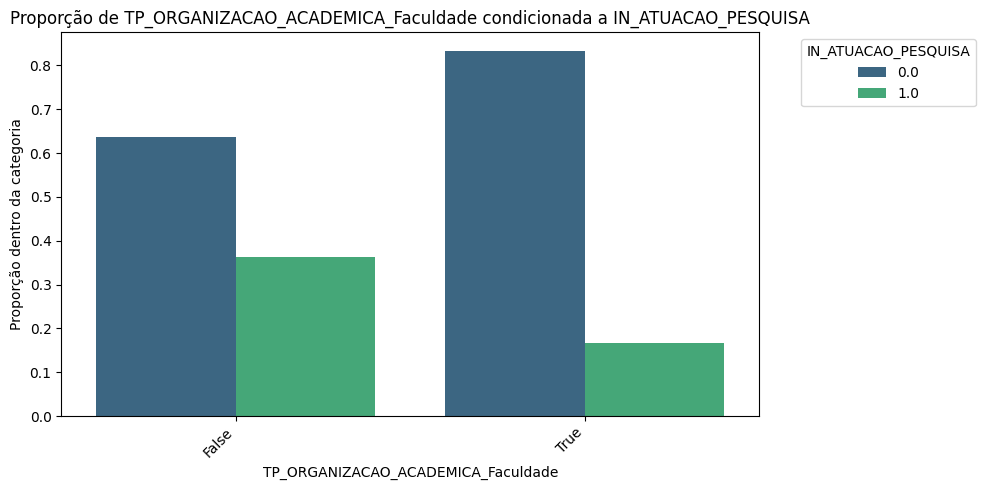

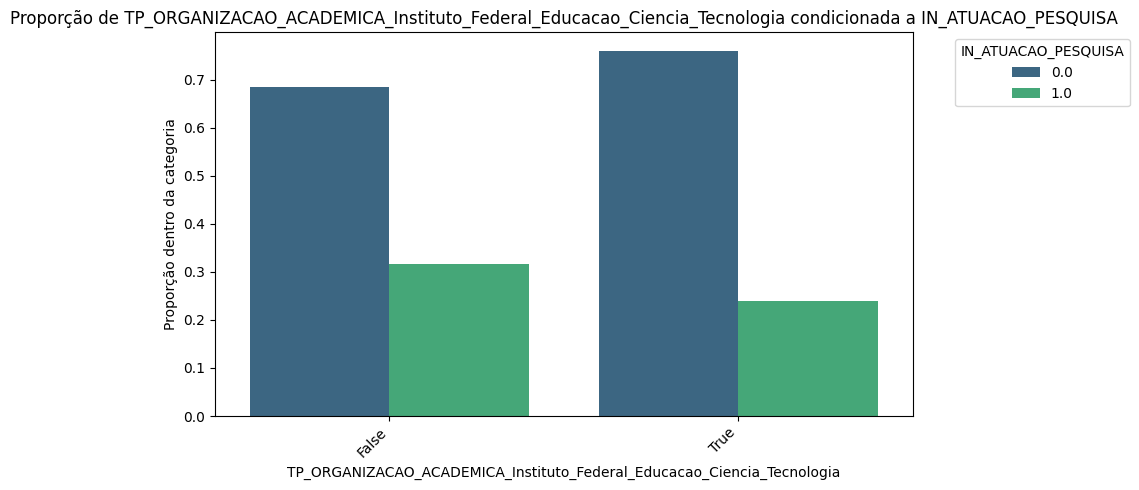

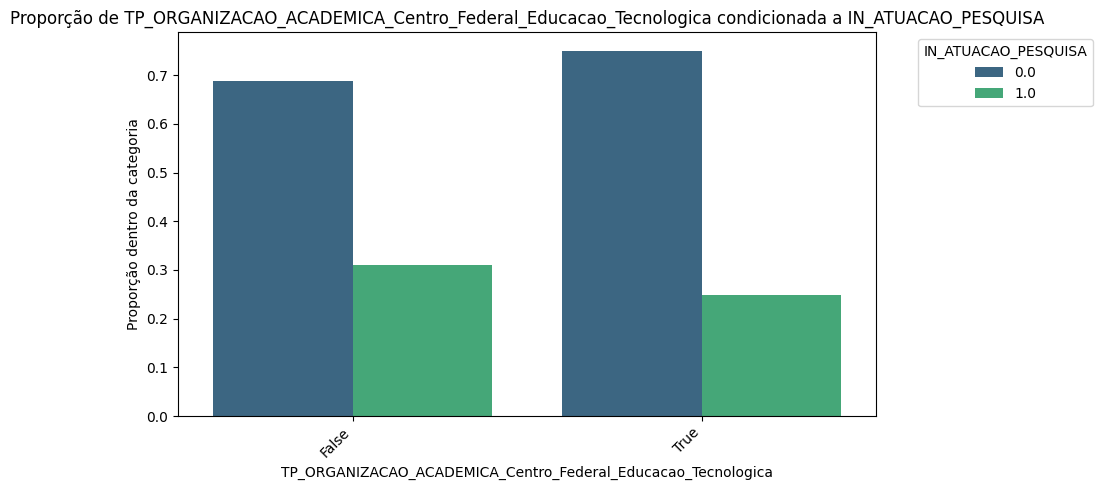

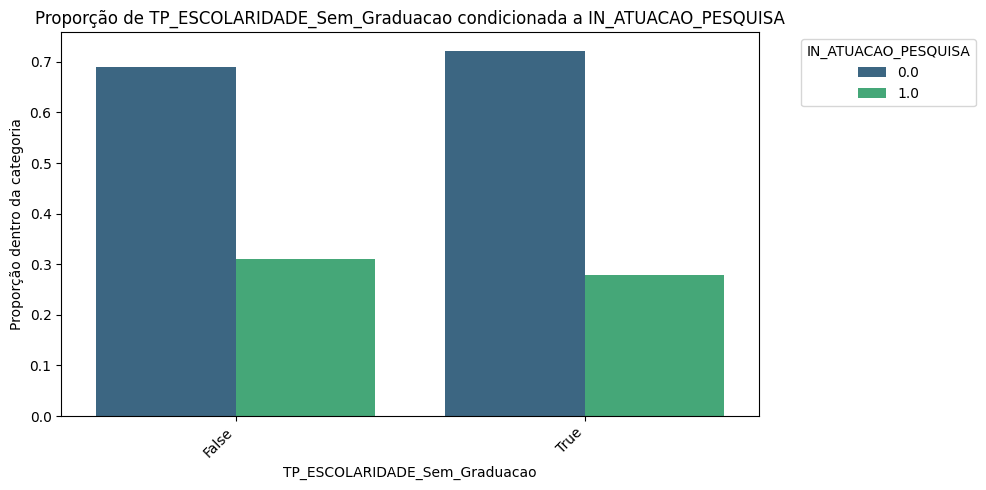

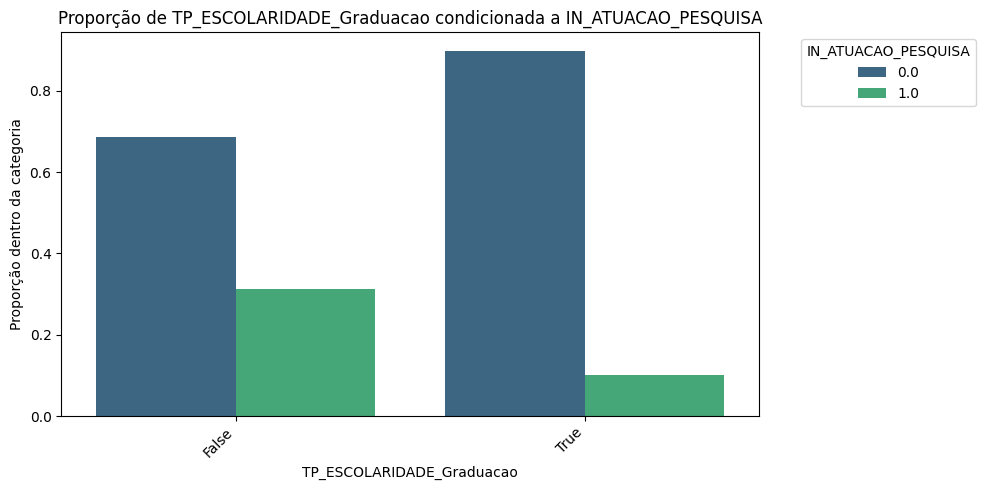

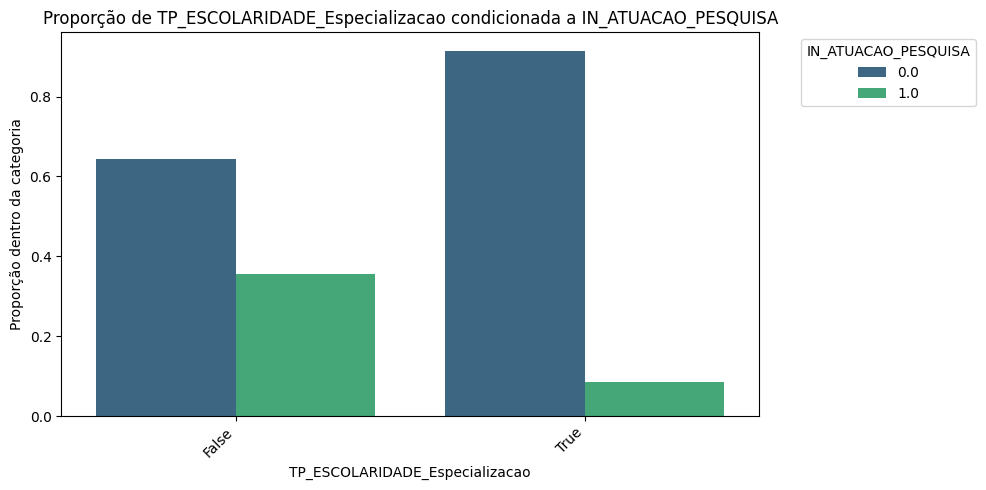

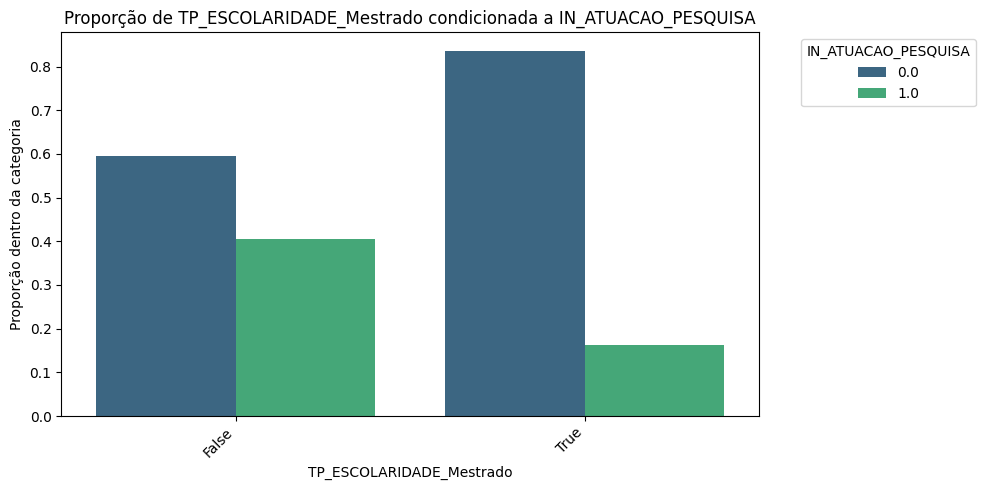

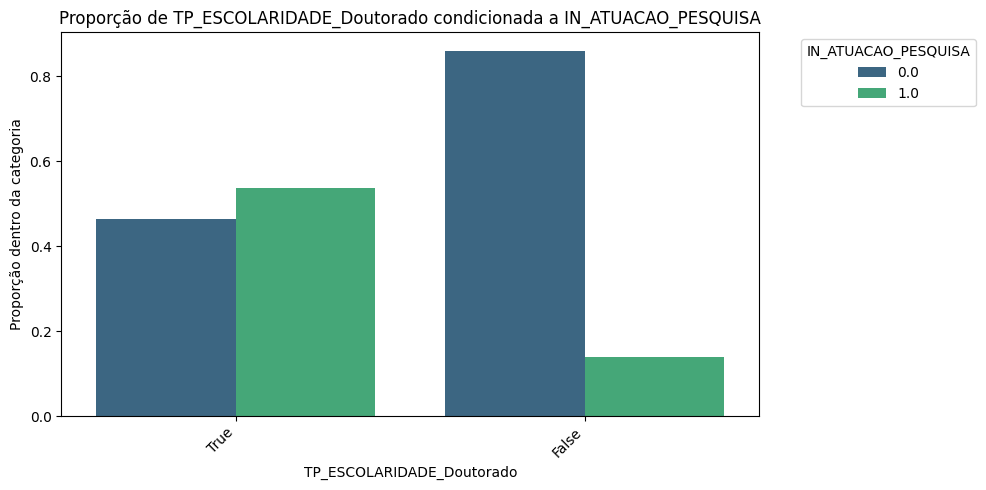

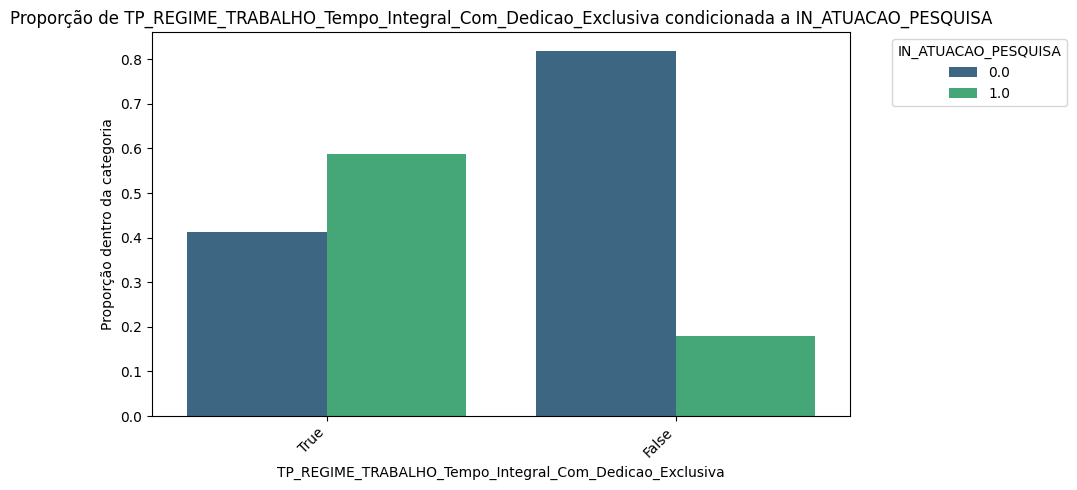

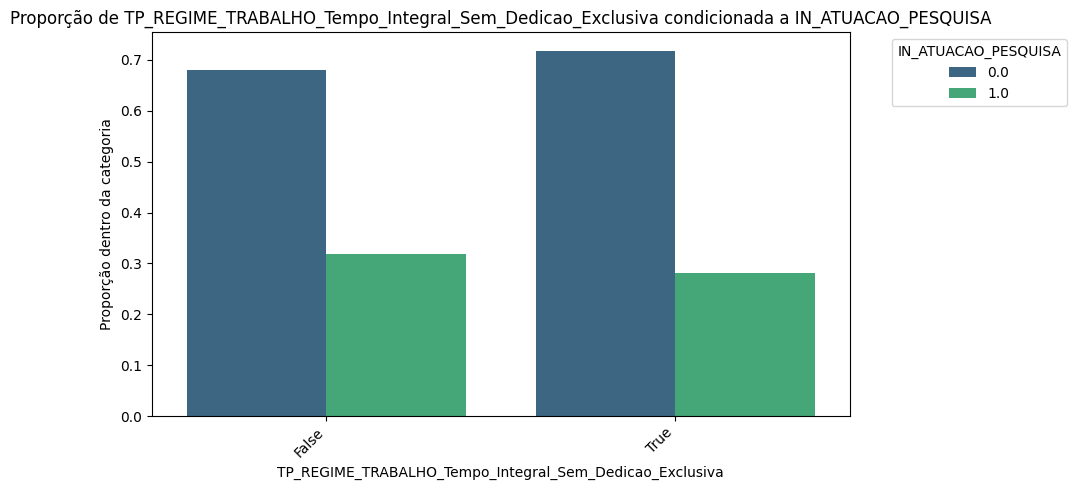

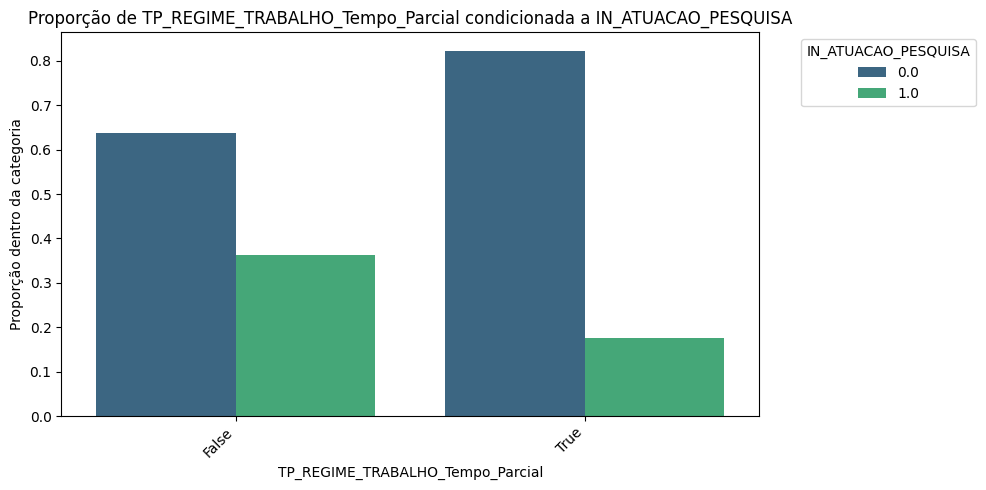

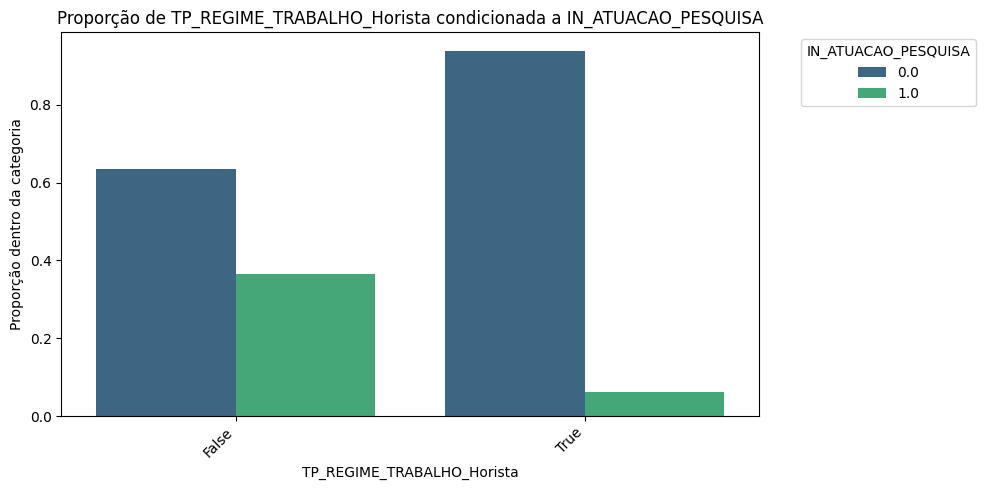

In [ ]:
target = "IN_ATUACAO_PESQUISA"

# detectar colunas categóricas (excluindo target)
cat_cols = [c for c in df_treinamento.select_dtypes(include=["category", "object", "bool"]).columns if c != target]

for col in cat_cols:
    try:
        # tabela de proporções por categoria (normalizada por linha = por categoria)
        ct = pd.crosstab(df_treinamento[col], df_treinamento[target], normalize='index')

        # garantir que a coluna do "positivo" exista; usar a última coluna como proxy se não for 0/1
        if 1 in ct.columns:
            pos_col = 1
        elif '1' in ct.columns:
            pos_col = '1'
        else:
            pos_col = ct.columns[-1]

        # ordem das categorias pela proporção da classe positiva (descendente)
        order = ct.sort_values(by=pos_col, ascending=False).index

        # transformar para long form para seaborn
        df_plot = ct.reset_index().melt(id_vars=col, var_name='target', value_name='proportion')

        plt.figure(figsize=(10, 5))
        sns.barplot(
            data=df_plot,
            x=col,
            y='proportion',
            hue='target',
            order=order,
            palette='viridis'
        )
        plt.title(f"Proporção de {col} condicionada a {target}")
        plt.ylabel("Proporção dentro da categoria")
        plt.xticks(rotation=45, ha='right')
        plt.legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Erro em '{col}': {e}")
        continue

### Countplots (todas)

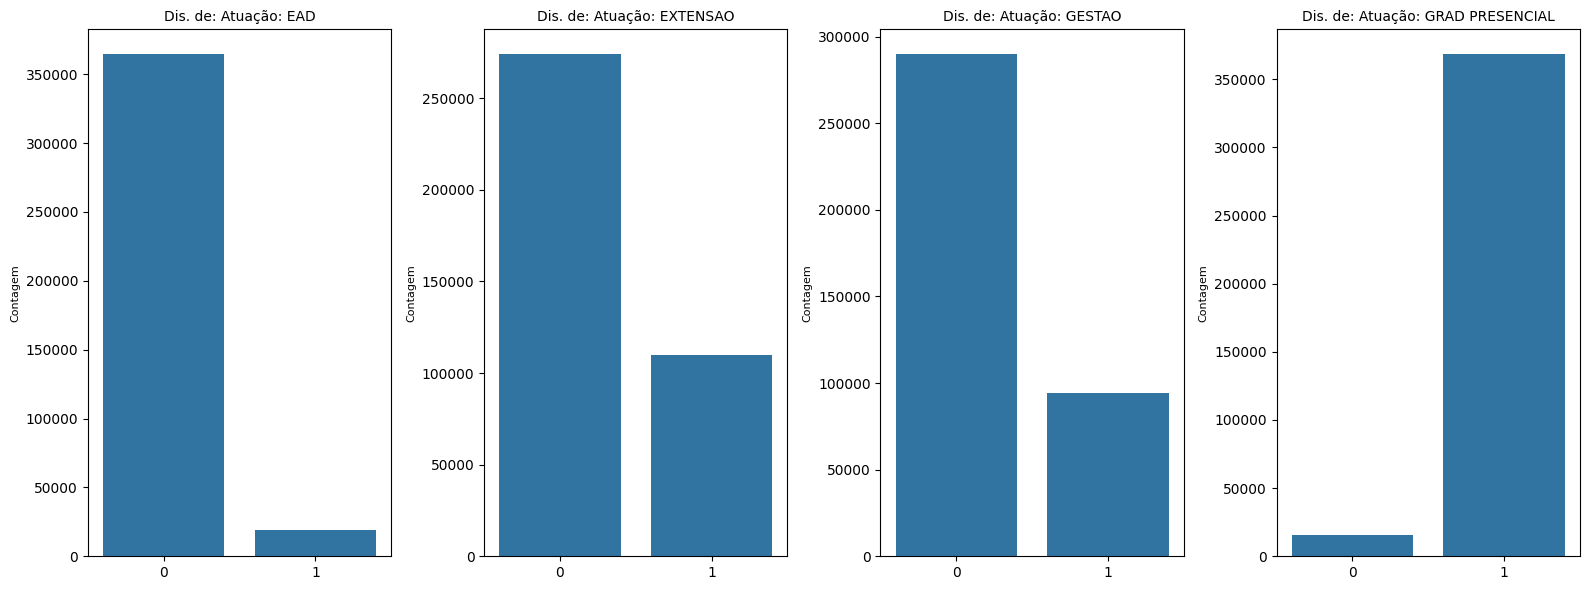

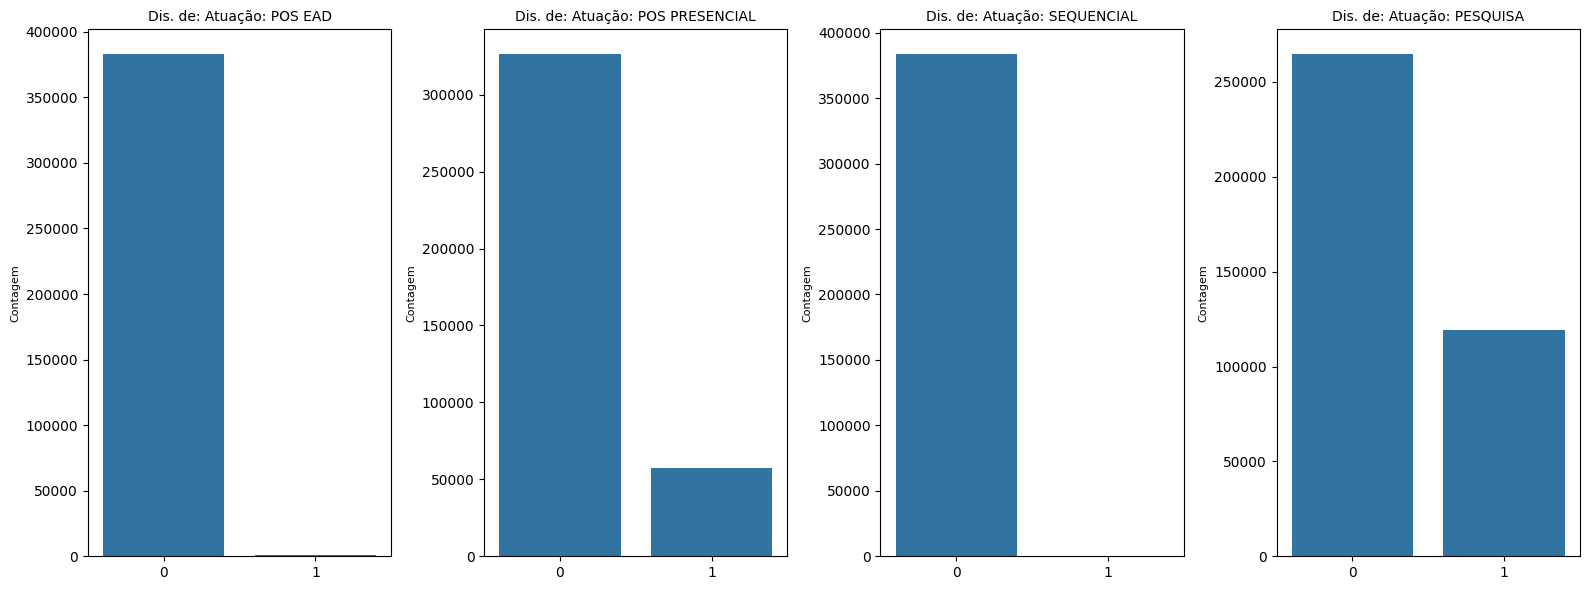

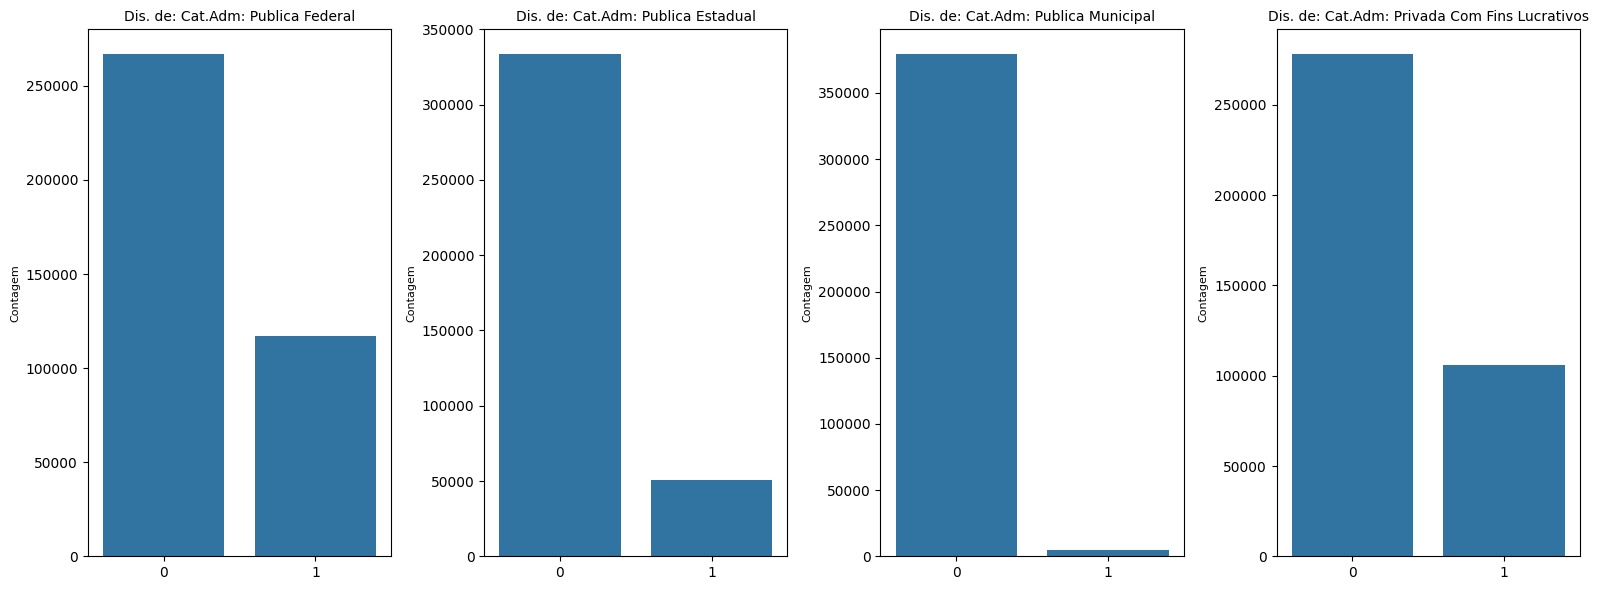

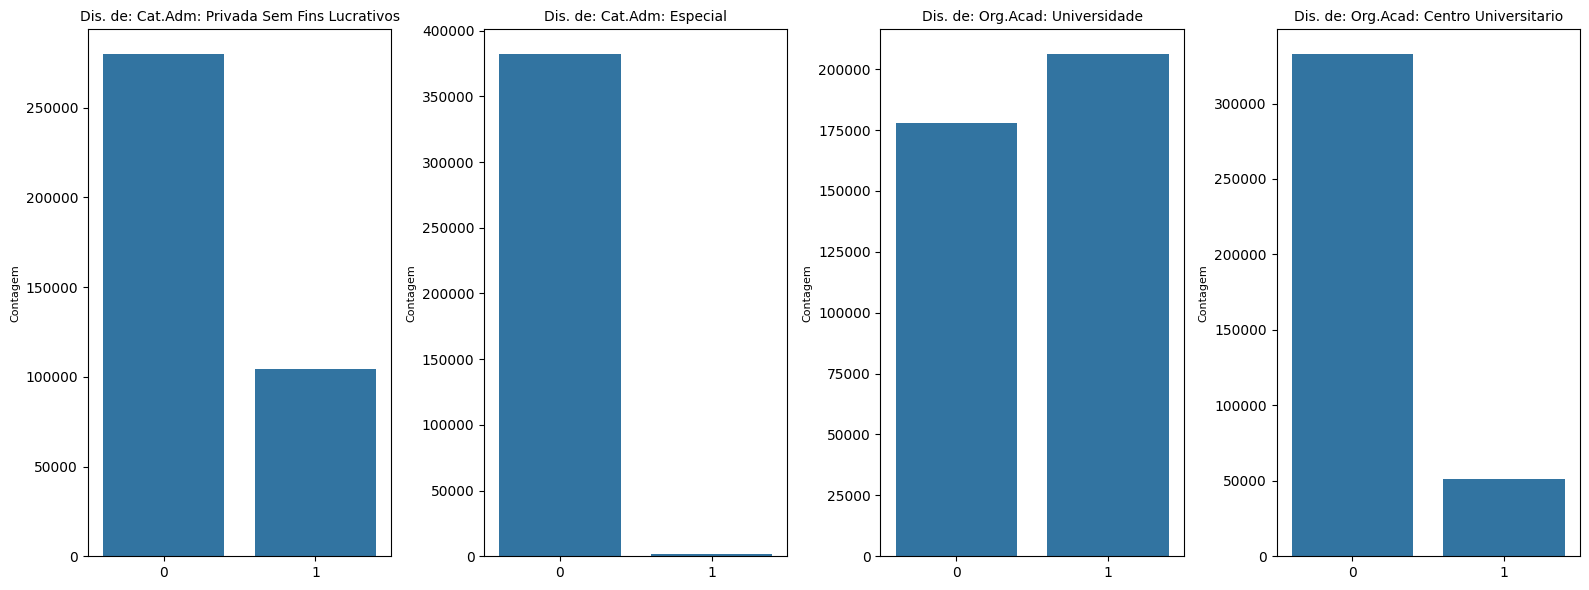

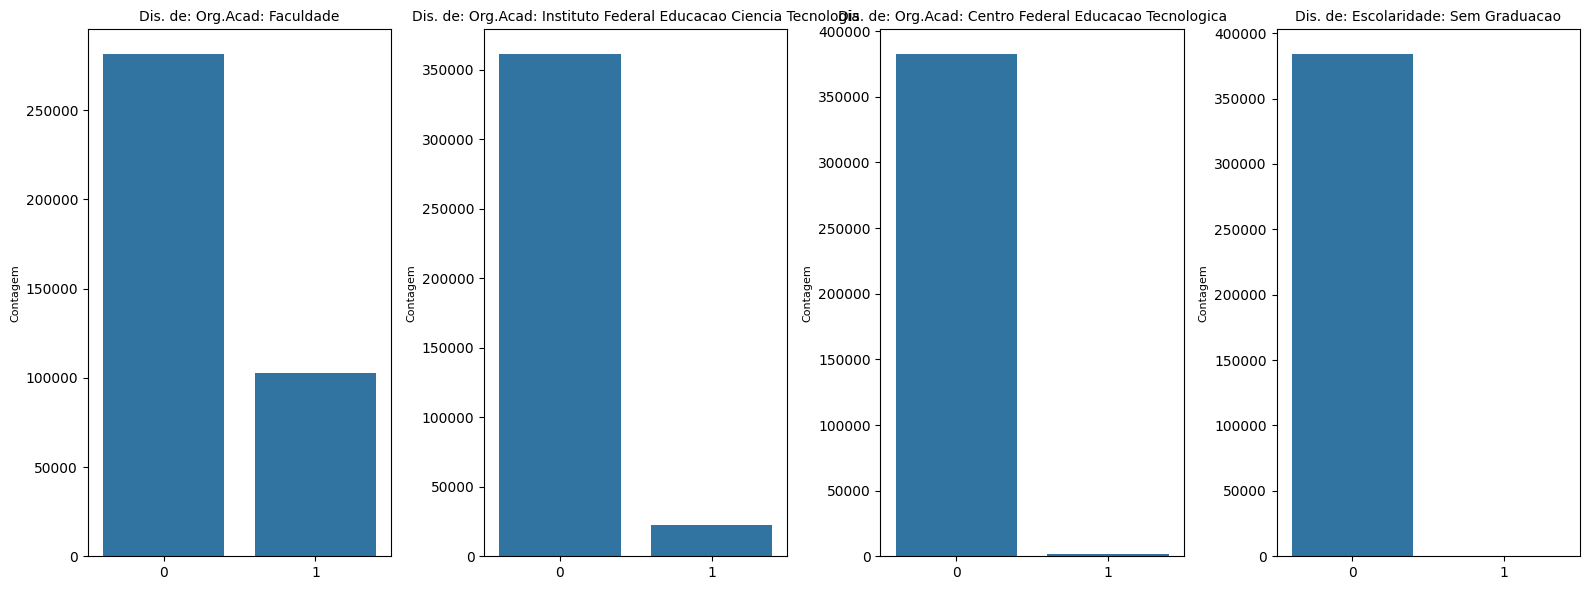

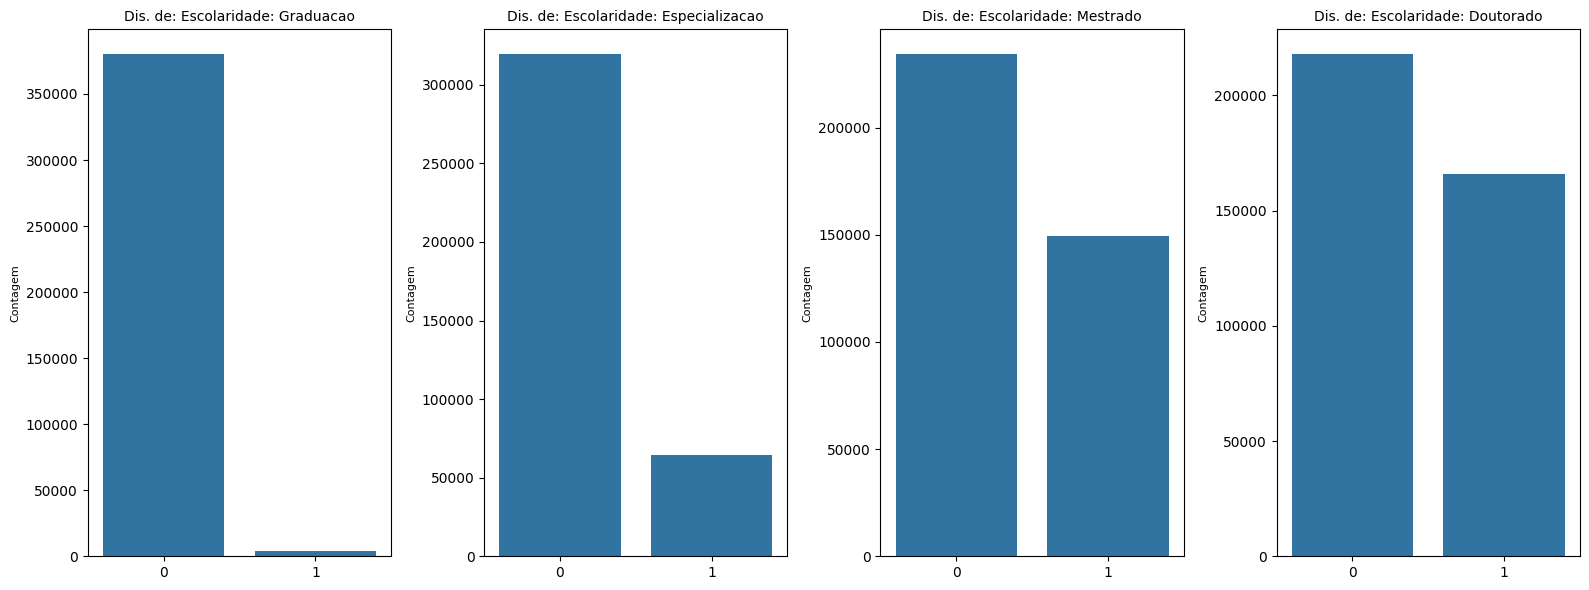

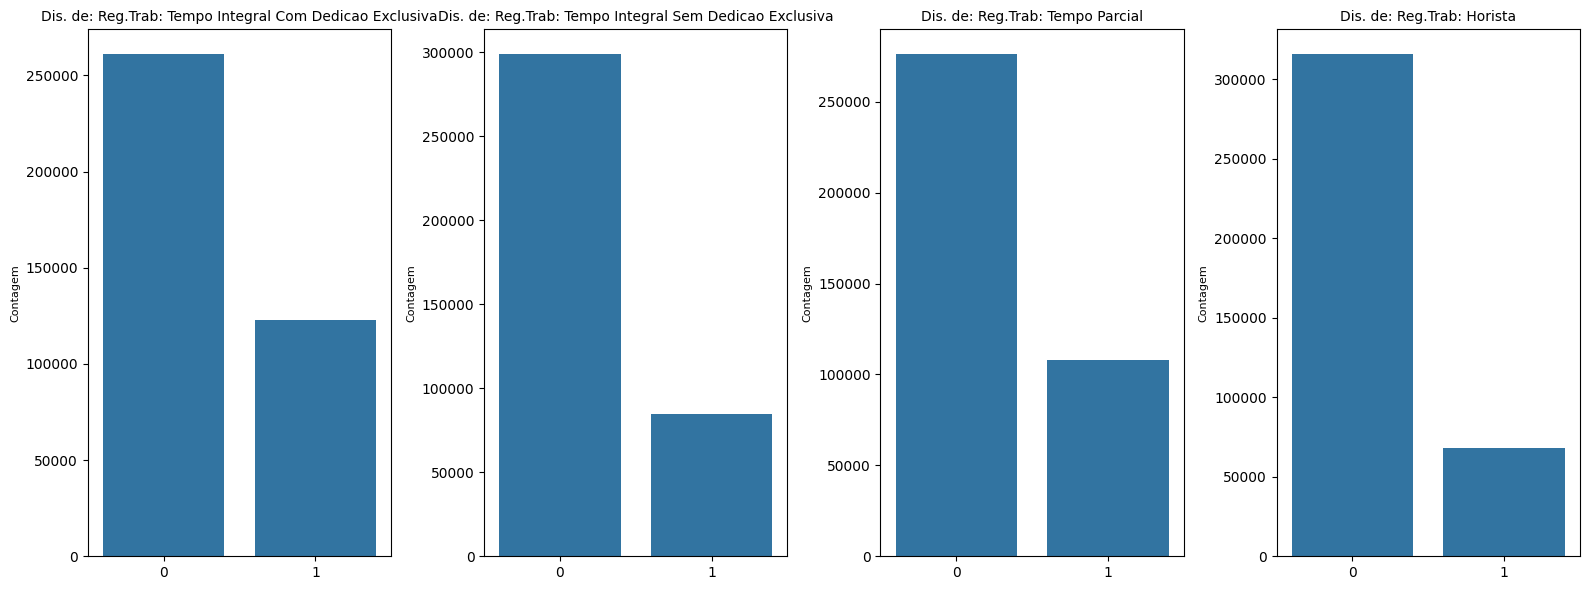

In [ ]:
binary_cols = [col for col in df_treinamento.columns if col != 'NU_IDADE']

# Função para formatar os nomes das colunas para os títulos
def format_title(col_name):
    # Remove prefixos comuns e substitui underscores por espaços
    formatted_name = col_name.replace('TP_CATEGORIA_ADMINISTRATIVA_', 'Cat.Adm: ')
    formatted_name = formatted_name.replace('TP_ORGANIZACAO_ACADEMICA_', 'Org.Acad: ')
    formatted_name = formatted_name.replace('TP_ESCOLARIDADE_', 'Escolaridade: ')
    formatted_name = formatted_name.replace('TP_REGIME_TRABALHO_', 'Reg.Trab: ')
    formatted_name = formatted_name.replace('IN_ATUACAO_', 'Atuação: ')
    formatted_name = formatted_name.replace('_', ' ')
    return formatted_name

# Definir o número de colunas por linha para os subplots
num_cols_per_row = 4
num_figures = (len(binary_cols) + num_cols_per_row - 1) // num_cols_per_row

for i in range(num_figures):
    fig, axes = plt.subplots(1, num_cols_per_row, figsize=(4 * num_cols_per_row, 6))
    axes = axes.flatten() # Achatar para facilitar a iteração, mesmo que seja apenas 1 linha

    for j in range(num_cols_per_row):
        col_idx = i * num_cols_per_row + j
        if col_idx < len(binary_cols):
            col = binary_cols[col_idx]
            sns.countplot(x=df_treinamento[col], ax=axes[j])
            axes[j].set_title(f'Dis. de: {format_title(col)}', fontsize=10, wrap=True)
            axes[j].set_xlabel('') # Limpar o rótulo x para evitar sobrecarga
            axes[j].set_ylabel('Contagem', fontsize=8)
            axes[j].set_xticks([0, 1])
            axes[j].set_xticklabels(['0', '1'])
        else:
            fig.delaxes(axes[j]) # Ocultar subplots vazios, se houver

    plt.tight_layout()
    plt.show()

# Normalização

In [ ]:
# Isso estava virando float64 (?)
# Update - ajustei a função de normalizar
df_treinamento["NU_IDADE"].dtype

dtype('uint8')

In [ ]:
df_treinamento_normalizado = normalizar_dados(df_treinamento)

> NOTA: Agora, pós-normalização, `NU_IDADE` está no range $[0,1]$.

In [ ]:
df_treinamento_normalizado.info(verbose=True, memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 383731 entries, 0 to 397892
Data columns (total 29 columns):
 #   Column                                                                  Non-Null Count   Dtype   
---  ------                                                                  --------------   -----   
 0   NU_IDADE                                                                383731 non-null  float16 
 1   IN_ATUACAO_EAD                                                          383731 non-null  category
 2   IN_ATUACAO_EXTENSAO                                                     383731 non-null  category
 3   IN_ATUACAO_GESTAO                                                       383731 non-null  category
 4   IN_ATUACAO_GRAD_PRESENCIAL                                              383731 non-null  category
 5   IN_ATUACAO_POS_EAD                                                      383731 non-null  category
 6   IN_ATUACAO_POS_PRESENCIAL                                        

# Tamanho Final dos Dados

In [ ]:
print(f"Tamanho dataset final   = {len(df_treinamento_normalizado):,}")
print(f"Quantidade de variáveis = {len(df_treinamento_normalizado.columns):,}")

Tamanho dataset final   = 383,731
Quantidade de variáveis = 29


# Correlações - Numérica (`NU_IDADE`)

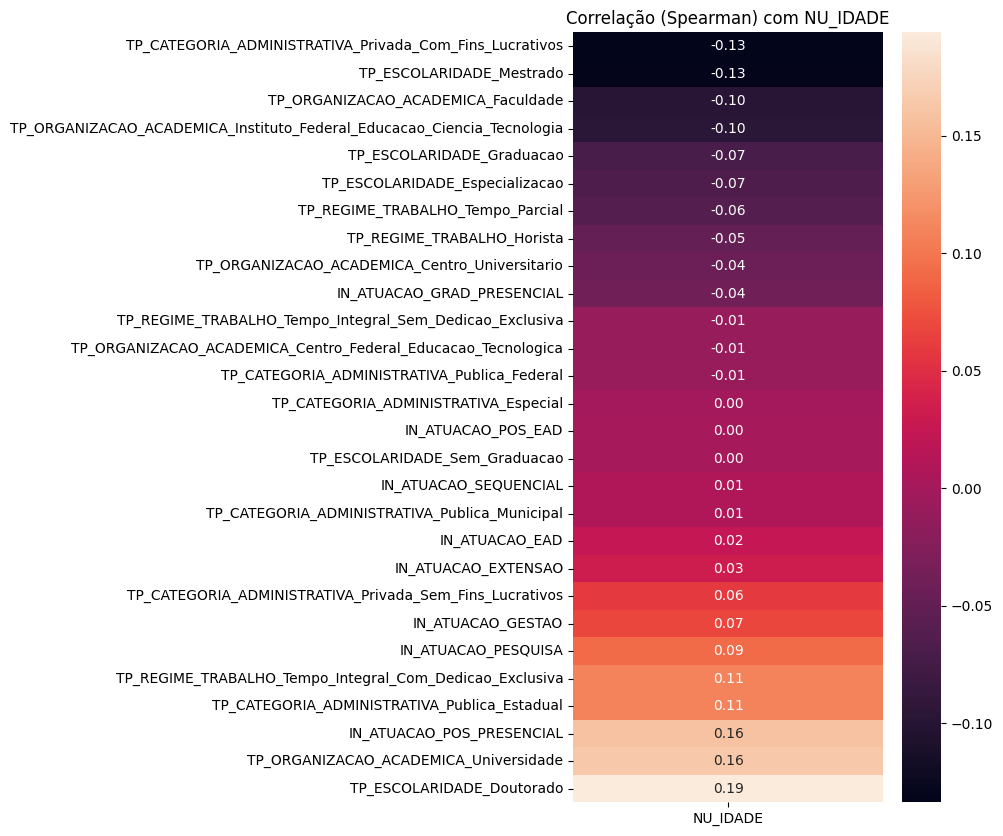

In [ ]:
# Selecionar apenas a coluna da correlação com a target (DF de 1 coluna)
target_corr = corr[['NU_IDADE']]

# Dropar a própria correlação com ela mesma
target_corr = target_corr.drop(index='NU_IDADE')

plt.figure(figsize=(5, 10))
sns.heatmap(
    target_corr.sort_values('NU_IDADE', ascending=True),
    annot=True,
    fmt=".2f",
    cmap="rocket",
    cbar=True
)
plt.title("Correlação (Spearman) com NU_IDADE")
plt.tight_layout()
plt.show()

> Todas baixas, nenhuma é $\geq 0,2$ (em módulo)

# Treinamento

Hora de rodar os modelos! Serão testados quatro:
1. K-Nearest Neighbours
2. Support Vector Machine
3. Naive-Bayes
4. Random Forest

> A variável do DF final é `df_treinamento_normalizado`

In [ ]:
df = df_treinamento_normalizado.copy()

> Massageando um pouco os dados e preparando a tabela de Resultados

In [ ]:
# 1. Preparar X e y
target = "IN_ATUACAO_PESQUISA"
X = df.drop(columns=[target])
y = df[target].astype(int)   # garante shape ok para todos os modelos

# split fixo p/ comparabilidade entre modelos (random state 42 padrão)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# dataframe que vai receber os resultados
df_resultados = pd.DataFrame(columns=[
    "Modelo", "Acurácia", "Precisão", "Recall", "F1", "TempoTreino (s)", "TempoTeste (s)"
])

> Relembrando rapidamente o que são as métricas

- Acurácia é a proporção total de acertos: $\frac{TP + TN}{TP + TN + FP + FN}$ (útil com classes balanceadas)
- Precisão é a proporção de positivos que são realmente positivos: $\frac{TP}{TP + FP}$ (quão confiáveis são as previsões positivas)
- Recall é quanto das instâncias positivas foram corretamente encontradas $\frac{TP}{TP + FN}$ (capacidade de não deixar passar positivos)
- F1-score é a média harmônica entre precisão e recall: $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ (equilibra os dois)

## K-NN

k-Nearest Neighbors:
- Classifica cada observação olhando para os $k$ vizinhos mais próximos no espaço das features;
- O rótulo escolhido é aquele mais frequente entre esses vizinhos;
- Não aprende parâmetros: toda a "aprendizagem" ocorre no momento da predição $\rightarrow$ tende a ser mais lento pra prever;
- Funciona melhor com features normalizadas, pois depende de distâncias.

In [ ]:
# k definido empiricamente como 7 (valor fixo para comparabilidade entre modelos)
modelo_knn = KNeighborsClassifier(n_neighbors=7)

start_train = time.time()
modelo_knn.fit(X_train, y_train)
tempo_treino = time.time() - start_train

start_test = time.time()
y_pred = modelo_knn.predict(X_test)
tempo_teste = time.time() - start_test

# métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# registrar no df_resultados
df_resultados.loc[len(df_resultados)] = [
    "KNN",
    acc,
    prec,
    rec,
    f1,
    tempo_treino,
    tempo_teste
]

In [ ]:
df_resultados

,Modelo,Acurácia,Precisão,Recall,F1,TempoTreino (s),TempoTeste (s)
0,KNN,0.80,0.70,0.64,0.67,0.08,232.52


## SVM

Support Vector Machine:
- O SVM cria uma fronteira de decisão que maximiza a margem entre as classes;
- Encontra um hiperplano que separa os dados com a maior distância possível dos pontos mais próximos (os vetores de suporte);
- Quando não há separação linear clara, usa-se um kernel (aqui o RBF) que mapeia os dados para um espaço de maior dimensão.

A função de decisão é dada por:
$$f(x) = \sum_{i=1}^{n} \alpha_i y_i K(x_i, x) + b$$
Onde $K$ é o kernel RBF: $$K(x, x') = \exp(-\gamma \|x - x'\|^2)$$

> UPDATE — Sobre o uso de SVM não lineares, aproximações e a decisão de migrar para `LinearSVC`


Durante os testes, o modelo `SVC(kernel='rbf')` apresentou tempo de treinamento inviável para o nosso volume de dados (≈383 mil amostras e 29 variáveis). SVMs com kernel RBF exigem a construção implícita da matriz de similaridade entre todos os pares de pontos, o que leva o custo temporal para a ordem de $O(n^2)$ e, em alguns casos, perto de $O(n^3)$ dependendo da implementação e do valor de `C`. Na prática, cada iteração envolve operações densas sobre uma matriz de quase **147 milhões de pares**, tornando o treinamento lento mesmo com parâmetros relaxados como `tol=1e{-2}` e `gamma='scale'`.

Pra contornar isso sem sacrificar totalmente a capacidade de capturar relações não lineares, puxei **aproximações de kernel**. Essas técnicas transformam o problema em algo próximo de um SVM linear no espaço expandido, trazendo o custo para algo quase linear em $n$. Em troca, perdemos um pouco de fidelidade da fronteira não linear. A precisão costuma cair um pouco, mas o tempo de treinamento cai bastante.

Dado o custo alto e o fato de que o objetivo do experimento é explorar modelos treináveis em escala, mudei `LinearSVC`, cuja complexidade cresce quase linearmente com o número de amostras. Esse método não utiliza kernel explícito; ele tenta encontrar diretamente um hiperplano linear de separabilidade máxima. Em cenários onde a fronteira verdadeira é moderadamente não linear, modelos lineares ainda podem manter desempenho competitivo quando há muitas dimensões explicativas — o que é no nosso caso (29 dimensões podem tornar uma separação aproximadamente linear bastante expressiva).

> Sobre `make_pipeline`

Ele constrói uma sequência ordenada de operações, como pré-processamento seguido do classificador, garantindo que:

1. O escalonamento (`StandardScaler`) seja calculado **somente** nos dados de **treino** e reaplicado nos dados de teste de forma consistente;
2. Não haja risco de *leakage* (informações vazando do teste para o treino);
3. A interface permaneça uniforme: `fit`, `predict`, `score`.

In [ ]:
# pipeline com normalização interna (ajuda o otimizador do LinearSVC)
modelo_lsvc = make_pipeline(
    StandardScaler(),
    LinearSVC(
        C=1.0,
        tol=1e-3,
        max_iter=5000,
        dual="auto" # deixa o sklearn decidir automaticamente (bom para alta dimensionalidade)
    )
)

start_train = time.time()
modelo_lsvc.fit(X_train, y_train)
tempo_treino = time.time() - start_train

start_test = time.time()
y_pred = modelo_lsvc.predict(X_test)
tempo_teste = time.time() - start_test

# métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# registrar no df_resultados
df_resultados.loc[len(df_resultados)] = [
    "LinearSVC",
    acc,
    prec,
    rec,
    f1,
    tempo_treino,
    tempo_teste
]

In [ ]:
df_resultados

,Modelo,Acurácia,Precisão,Recall,F1,TempoTreino (s),TempoTeste (s)
0,KNN,0.80,0.70,0.64,0.67,0.08,232.52
1,LinearSVC,0.81,0.76,0.57,0.65,1.69,0.09


## NB

O `Multinomial Naive Bayes` é projetado para lidar com contagens discretas.

Quando usamos one-hot, cada coluna categórica se transforma em uma variável binária (0/1). Isso é essencialmente uma contagem de eventos — se a categoria "aconteceu" para aquele padrão específico.

Então, as suposições do `MultinomialNB` se encaixam melhor que as suposições de normalidade de um `GaussianNB`. Ele enxerga diretamente as frequências relativas das categorias, sem impor uma distribuição contínua artificial.

Isso faz com que o ele produza melhores resultados, pois:
- as features são quase todas binárias ou contagens discretas
- há muitas dimensões ($29$, especificamente pro nosso caso)
- há apenas uma feature contínuas (`NU_IDADE`)

Principais hiperparâmetros:
- $ \alpha $ — suavização de Laplace (evita probabilidades zero).
- `fit_prior` — se deve estimar automaticamente $ P(y) $.

> Pipeline novamente, pois os dados contém valores negativos.

In [ ]:
col_idade = ["NU_IDADE"]
col_onehot = [c for c in X_train.columns if c not in col_idade]

pipeline_stacking = Pipeline([
    ("preproc", ColumnTransformer(
        transformers=[
            ("idade", MinMaxScaler(), col_idade),     # remove negativos
            ("cat", "passthrough", col_onehot)
        ],
        remainder="drop"
    )),
    ("modelo", StackingClassifier(
        estimators=[
            ("gauss", GaussianNB()),
            ("multi", MultinomialNB()),
        ],
        final_estimator=LogisticRegression(max_iter=500),
        stack_method="predict_proba",
        n_jobs=-1
    ))
])

modelo_stacking = pipeline_stacking

In [ ]:
start_train = time.time()
modelo_stacking.fit(X_train, y_train)
tempo_treino = time.time() - start_train

start_test = time.time()
y_pred = modelo_stacking.predict(X_test)
tempo_teste = time.time() - start_test

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

df_resultados.loc[len(df_resultados)] = [
    "StackingNB",
    acc,
    prec,
    rec,
    f1,
    tempo_treino,
    tempo_teste
]

In [ ]:
df_resultados

,Modelo,Acurácia,Precisão,Recall,F1,TempoTreino (s),TempoTeste (s)
0,KNN,0.80,0.70,0.64,0.67,0.08,232.52
1,LinearSVC,0.81,0.76,0.57,0.65,1.69,0.09
2,StackingNB,0.79,0.68,0.64,0.66,15.20,0.53


## RF

Random Forest é um modelo baseado em um conjunto de árvores de decisão independentes: cada árvore recebe um *bootstrap* dos dados (amostra aleatória com reposição) e, em cada divisão, considera apenas um subconjunto aleatório de variáveis

Essa combinação de **bootstrap + seleção aleatória de features** reduz fortemente o overfitting típico das árvores individuais.

No fim, cada árvore vota, e a floresta decide pela maioria. A mágica está na variância reduzida: ao combinar árvores fracas mas diversas, o conjunto se torna forte.

Hiperparâmetros principais:
- `n_estimators`: número de árvores
- `max_depth`: profundidade máxima (controla complexidade)
- `max_features`: número de atributos considerados por split
- `bootstrap`: se usa amostragem com reposição

Para dados mistos (nosso caso, categóricos one-hot + 1 numérico normalizado), funciona muito bem, pois árvores não exigem escalonamento e lidam bem com interações complexas.

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=300,       # logicamente um número legal
    max_depth=None,         # deixa crescer mesmo e prosseguir com a etapa
    n_jobs=-1,              # paralelizar pra acelerar
    bootstrap=True,         # amostrar com reposição
    random_state=42         # reprodutibilidade
)

start_train = time.time()
modelo_rf.fit(X_train, y_train)
tempo_treino = time.time() - start_train

start_test = time.time()
y_pred = modelo_rf.predict(X_test)
tempo_teste = time.time() - start_test

# métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

df_resultados.loc[len(df_resultados)] = [
    "RandomForest",
    acc,
    prec,
    rec,
    f1,
    tempo_treino,
    tempo_teste
]

In [ ]:
df_resultados

,Modelo,Acurácia,Precisão,Recall,F1,TempoTreino (s),TempoTeste (s)
0,KNN,0.80,0.70,0.64,0.67,0.08,232.52
1,LinearSVC,0.81,0.76,0.57,0.65,1.69,0.09
2,StackingNB,0.79,0.68,0.64,0.66,15.20,0.53
3,RandomForest,0.81,0.72,0.65,0.68,78.35,7.27


# Salvando os Arquivos


Vamos salvar em um arquivo, pra não ter que ficar meia hora re-rodando tudo toda vez.

> Parquet fica ótimo pra salvar, porque o dataset é largo e repete muitas colunas one-hot, então a compressão ajuda demais.

In [ ]:
df_treinamento.to_csv("/content/df_treinamento.csv", index=False)
df_treinamento.to_parquet("/content/df_treinamento.parquet", index=False)

print("DF de Treino salvo em `/content`")

DF de Treino salvo em `/content`


> Update: CSV ficou em ~55MB e Parquet <800KB

Vamos salvar também os resultados.

In [ ]:
df_resultados.to_csv("/content/df_resultados.csv", index=False)
df_resultados.to_parquet("/content/df_resultados.parquet", index=False)

print("Resultados salvos em `/content`")

Resultados salvos em `/content`


Vamos salvar também os modelos.

In [ ]:
base_dir = "/content/modelos"
os.makedirs(base_dir, exist_ok=True)

joblib.dump(modelo_knn,      f"{base_dir}/modelo_knn.joblib")
joblib.dump(modelo_lsvc,     f"{base_dir}/modelo_lsvc.joblib")
joblib.dump(modelo_stacking, f"{base_dir}/modelo_stacking.joblib")
joblib.dump(modelo_rf,       f"{base_dir}/modelo_rf.joblib")

print("Modelos salvos em", base_dir)

Modelos salvos em /content/modelos


# Métricas Finais

In [ ]:
df_resultados

,Modelo,Acurácia,Precisão,Recall,F1,TempoTreino (s),TempoTeste (s)
0,KNN,0.80,0.70,0.64,0.67,0.08,232.52
1,LinearSVC,0.81,0.76,0.57,0.65,1.69,0.09
2,StackingNB,0.79,0.68,0.64,0.66,15.20,0.53
3,RandomForest,0.81,0.72,0.65,0.68,78.35,7.27


> Visualizando:

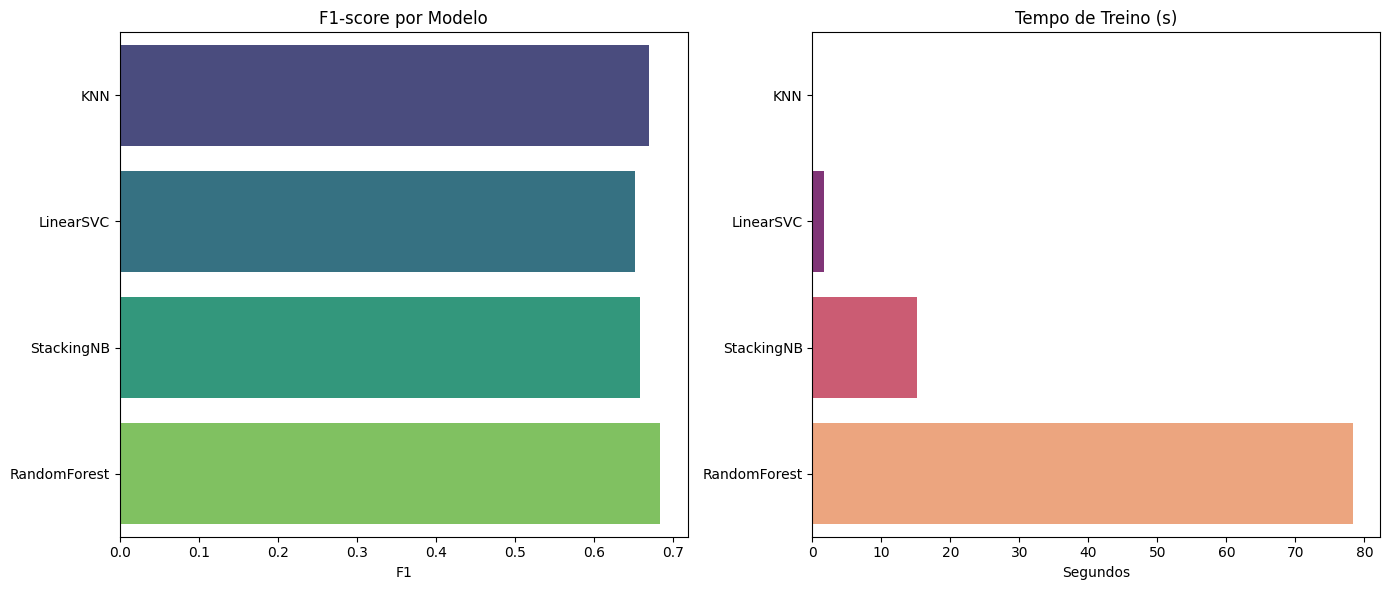

In [ ]:
df_plot = df_resultados.copy()
df_plot = df_plot.set_index("Modelo")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# F1-score
sns.barplot(
    x=df_plot["F1"],
    y=df_plot.index,
    ax=ax[0],
    palette="viridis"
)
ax[0].set_title("F1-score por Modelo")
ax[0].set_xlabel("F1")
ax[0].set_ylabel("")

# Tempo de treino
sns.barplot(
    x=df_plot["TempoTreino (s)"],
    y=df_plot.index,
    ax=ax[1],
    palette="magma"
)
ax[1].set_title("Tempo de Treino (s)")
ax[1].set_xlabel("Segundos")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

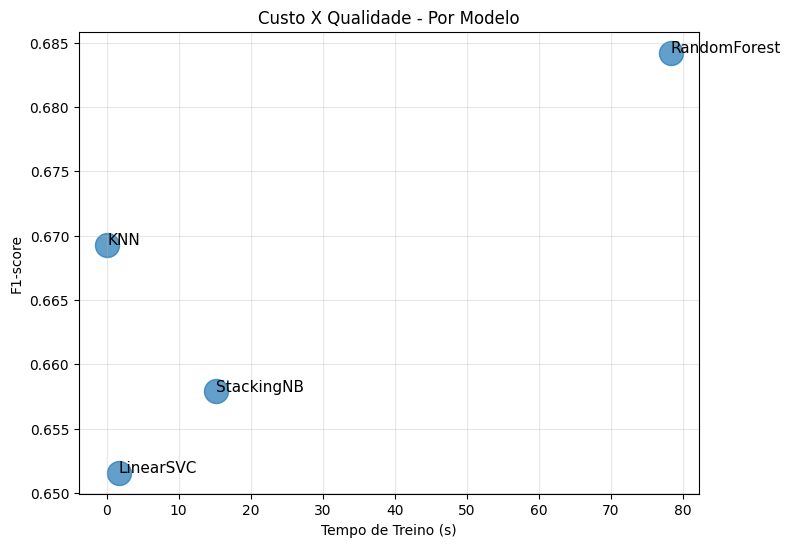

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_resultados["TempoTreino (s)"],
    df_resultados["F1"],
    s=300,
    alpha=0.7
)

for i, row in df_resultados.iterrows():
    plt.text(row["TempoTreino (s)"], row["F1"], row["Modelo"], fontsize=11)

plt.xlabel("Tempo de Treino (s)")
plt.ylabel("F1-score")
plt.title("Custo X Qualidade - Por Modelo")
plt.grid(alpha=0.3)
plt.show()

> Tudo junto

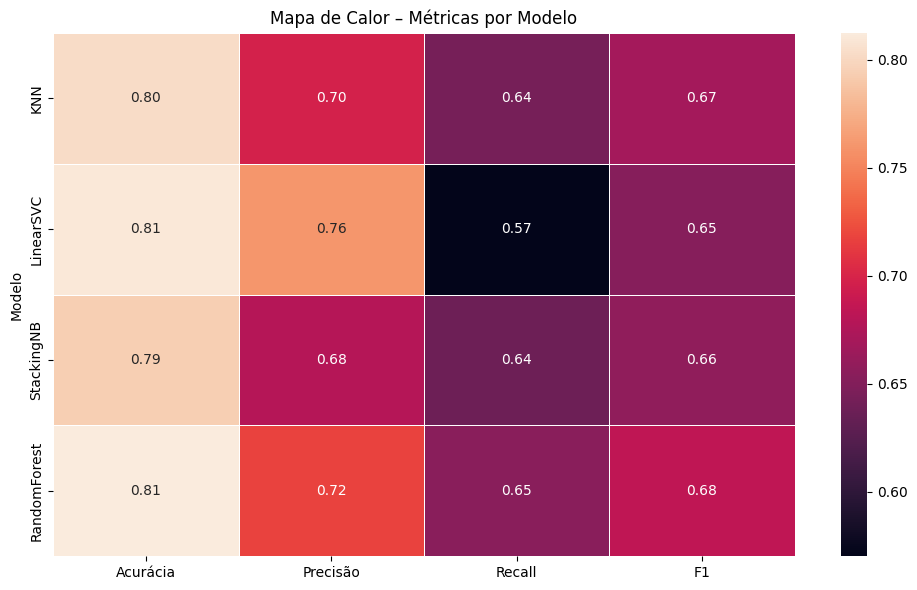

In [ ]:
metric_cols = ["Acurácia", "Precisão", "Recall", "F1"]

plt.figure(figsize=(10, 6))
sns.heatmap(df_resultados.set_index("Modelo")[metric_cols],
            annot=True, fmt=".2f", cmap="rocket", linewidths=.5)

plt.title("Mapa de Calor – Métricas por Modelo")
plt.tight_layout()
plt.show()

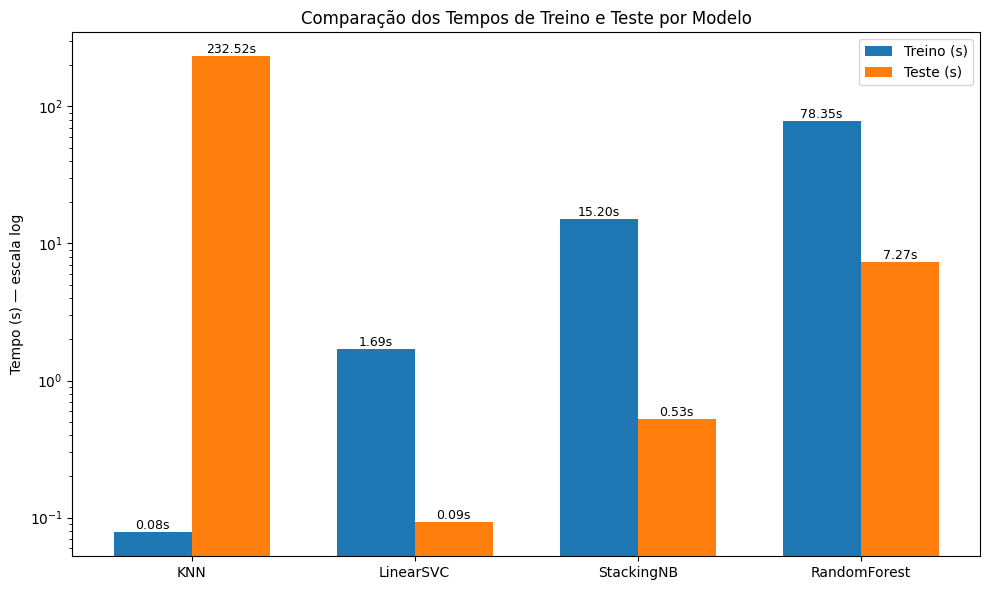

In [ ]:
modelos = df_resultados["Modelo"].values
treino = df_resultados["TempoTreino (s)"].values
teste = df_resultados["TempoTeste (s)"].values

x = np.arange(len(modelos))
largura = 0.35

plt.figure(figsize=(10,6))

# barras
b1 = plt.bar(x - largura/2, treino, width=largura, label="Treino (s)")
b2 = plt.bar(x + largura/2, teste,  width=largura, label="Teste (s)")

plt.yscale("log")
plt.xticks(x, modelos)
plt.ylabel("Tempo (s) — escala log")
plt.title("Comparação dos Tempos de Treino e Teste por Modelo")
plt.legend()

# --- ANOTAÇÕES ---
for bar in b1:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.2f}s",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in b2:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.2f}s",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

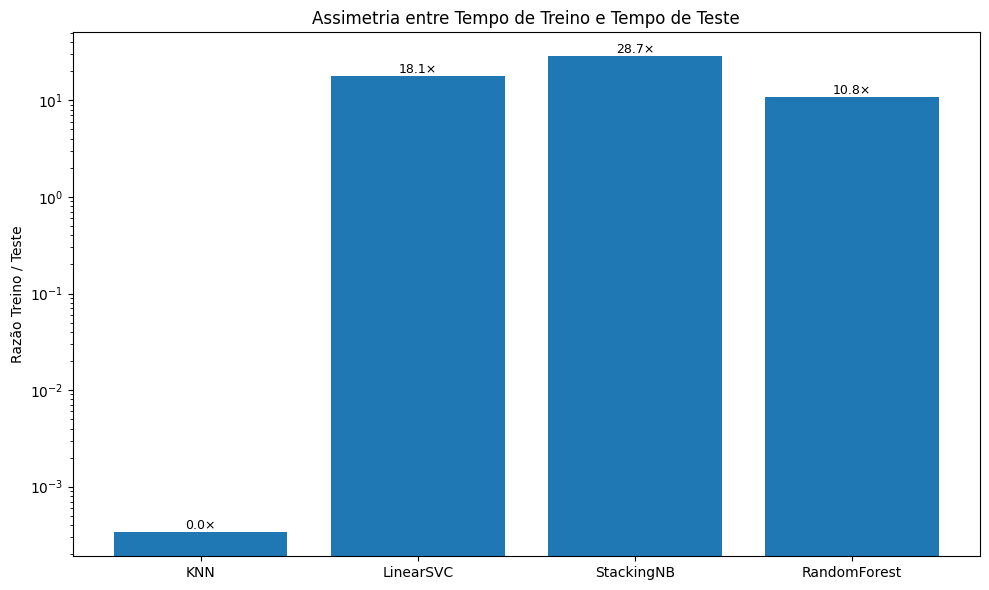

In [ ]:
modelos = df_resultados["Modelo"]
treino = df_resultados["TempoTreino (s)"].values
teste = df_resultados["TempoTeste (s)"].values

ratio = treino / teste

plt.figure(figsize=(10, 6))
bars = plt.bar(modelos, ratio)

plt.yscale("log")
plt.ylabel("Razão Treino / Teste")
plt.title("Assimetria entre Tempo de Treino e Tempo de Teste")

# --- ANOTAÇÕES ---
for bar, value in zip(bars, ratio):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}×",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Fim